# 04 · Modelo 1X2: ¿qué decide un partido?

**Pregunta central:** ¿qué decide un partido de LaLiga: la fuerza, la forma, el estilo o el azar?

**Decisiones de esta fase**

| Decisión | Elección | Motivo |
|---|---|---|
| Validación | Progresiva (*walk-forward*), ventana creciente desde 2014/15: 5 pliegues que validan 2019/20 a 2023/24 | Cada temporada se predice solo con las anteriores, como en la realidad |
| Test | **2024/25 y 2025/26 (760 partidos), intactas hasta el final** | Nota final con datos que no se usaron para elegir el modelo, sus variables ni la regularización (salvedad en la sección 12) |
| Métricas | **RPS** (principal), *log-loss* (secundaria), acierto (para comunicar), calibración (diagnóstico) | El RPS respeta el orden 1 > X > 2 y es el estándar en fútbol |
| Referencias | 0: uniforme · 1: frecuencias históricas · 2: solo Elo (mismo modelo, una variable) · "siempre local" para el acierto | El listón, al no usar cuotas |
| Fuerza y forma | Diferencias local − visitante: `elo_dif`, `forma_puntos_dif`, `forma_xg_dif_dif` | Pocas variables; lo que importa es quién está mejor |
| Exclusiones | Partidos con un ascendido en sus 5 primeros partidos, sin 5 partidos de forma en xG (calentamiento de 2014/15) o sin 10 partidos en la ventana de estilo | Sin inventar valores. **Todos los modelos se evalúan sobre los mismos partidos** |
| Estilo | 6 coordenadas por equipo con los **19 partidos anteriores** (mínimo 10), estandarizadas con la **referencia de la temporada anterior** y descontada la calidad con una regresión **ajustada solo con el entrenamiento de cada pliegue** | Sin fuga de información |
| Choque de estilos | 2 interacciones fijadas de antemano: presión local × posesión visitante (I1) y posesión local × presión visitante (I2) | Hipótesis futbolística previa; probar todas sería sobreajuste |
| Pregunta central | Bloques **añadidos en orden** (historia) y **quitados uno a uno** del modelo completo (lo que cada bloque aporta en exclusiva) | El orden influye en lo que se atribuye a cada bloque |
| ¿Mejora real? | *Bootstrap* emparejado por partido (IC 95 %) + consistencia entre los 5 pliegues | Las diferencias son pequeñas; hay que separarlas del ruido |
| Azar | "Techo informativo": modelo con el xG **del propio partido** (información posterior, **no es una predicción**) | Separa lo que se sabe antes del partido, lo que se decide en el juego y el azar |
| Modelo | Regresión logística **ordinal** con regularización *ridge* (intensidad elegida dentro del entrenamiento); *gradient boosting* como comprobación | Respeta el orden de los resultados y es interpretable |


## 0. Preparación

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"
sys.path.insert(0, str(ROOT / "src"))        # funciones del proyecto: src/laliga/ (probadas en tests/)
from laliga.estilo import COORD, INTERACCIONES, NOMBRES_COORD, VARIABLES_ESTILO, coordenadas_estilo
from laliga.metricas import evaluar, log_loss, rps
from laliga.ordinal import LAMBDAS, RegresionOrdinal
from laliga.ordinal import ajustar_ordinal as _ajustar_ordinal
from laliga.validacion import TEMPORADAS_TEST, TEMPORADAS_VALIDACION, pliegues_walk_forward

con = duckdb.connect(config={"threads": 1})   # un hilo: las sumas siempre en el mismo orden (resultados idénticos byte a byte)
for tabla in ("partidos", "partidos_equipo", "forma_elo", "estilos_equipo_temporada"):
    con.sql(f"CREATE VIEW {tabla} AS SELECT * FROM read_csv('{(PROCESSED / f'{tabla}.csv').as_posix()}')")

SERIE, TINTA, TINTA_2, FONDO, REJILLA = "#2a78d6", "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"
# Validación: 2019/20–2023/24 (walk-forward) · test: 2024/25–2025/26 (definidas en src/laliga/validacion.py)
print("Validación:", TEMPORADAS_VALIDACION, "· test:", TEMPORADAS_TEST)


Validación: ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24'] · test: ['2024-25', '2025-26']


## 1. Ventana de estilo previa a cada partido

Para cada equipo y partido sumamos las piezas de sus **19 partidos anteriores** de la misma etapa en Primera (`ROWS BETWEEN 19 PRECEDING AND 1 PRECEDING`: el partido actual nunca entra). Solo cuentan partidos con datos de Understat. Con las sumas calculamos los ratios como cociente de sumas, igual que en la fase 3.

`n_estilo` guarda cuántos partidos entran en la ventana (se exigirá un mínimo de 10).

In [2]:
con.sql("""
CREATE OR REPLACE TABLE ventana_estilo AS
WITH base AS (
    SELECT pe.id_partido, pe.equipo, pe.temporada, pe.fecha, fe.etapa,
           pe.xg_favor IS NOT NULL AS con_understat,
           pe.ppda_pases, pe.ppda_acciones, pe.ppda_pases_rival, pe.ppda_acciones_rival,
           pe.pases_profundos_favor, pe.xg_favor, pe.tiros_favor, pe.xg_contra, pe.tiros_contra,
           CASE WHEN pe.xg_favor IS NOT NULL THEN pe.faltas_cometidas END AS faltas,
           CASE WHEN pe.xg_favor IS NOT NULL THEN fe.elo_antes END        AS elo_con_understat
    FROM partidos_equipo pe
    JOIN forma_elo fe USING (id_partido, equipo)
)
SELECT id_partido, equipo, temporada,
       count(ppda_pases)                                         OVER w AS n_estilo,
       sum(ppda_pases) OVER w / sum(ppda_acciones) OVER w                AS ppda,
       sum(ppda_pases_rival) OVER w / sum(ppda_acciones_rival) OVER w    AS ppda_rival,
       avg(pases_profundos_favor)                                OVER w AS profundos_pp,
       sum(xg_favor) OVER w / sum(tiros_favor) OVER w                    AS xg_por_tiro,
       sum(xg_contra) OVER w / sum(tiros_contra) OVER w                  AS xg_por_tiro_contra,
       avg(faltas)                                               OVER w AS faltas_pp,
       avg(elo_con_understat)                                    OVER w AS elo_medio
FROM base
WINDOW w AS (PARTITION BY equipo, etapa ORDER BY fecha, id_partido
             ROWS BETWEEN 19 PRECEDING AND 1 PRECEDING)
""")
con.sql("SELECT * FROM ventana_estilo WHERE equipo = 'Getafe' AND temporada = '2019-20' LIMIT 3").df()

,id_partido,equipo,temporada,n_estilo,ppda,ppda_rival,profundos_pp,xg_por_tiro,xg_por_tiro_contra,faltas_pp,elo_medio
0,2668,Getafe,2019-20,19,7.639794,5.657431,4.894737,0.129601,0.125515,16.052632,1535.635166
1,2674,Getafe,2019-20,19,7.952548,5.845361,4.789474,0.124579,0.139121,16.315789,1537.277431
2,2683,Getafe,2019-20,19,7.864043,5.746154,4.842105,0.124519,0.135502,15.736842,1537.839931


**Comprobación de fuga** (añadida en la auditoría final): recalculamos la ventana con pandas (`shift(1)` excluye el partido actual y `rolling(19)` suma los 19 anteriores). Si SQL y pandas coinciden en todas las filas, la ventana de estilo no usa el propio partido ni ninguno posterior.

In [3]:
ve_base = con.sql("""
SELECT pe.id_partido, pe.equipo, pe.fecha, fe.etapa, pe.ppda_pases, pe.ppda_acciones
FROM partidos_equipo pe JOIN forma_elo fe USING (id_partido, equipo)
ORDER BY pe.equipo, fe.etapa, pe.fecha, pe.id_partido
""").df()
g = ve_base.groupby(["equipo", "etapa"])
anteriores = lambda s: s.shift(1).rolling(19, min_periods=1)
ve_base["ppda_pandas"] = g.ppda_pases.transform(lambda s: anteriores(s).sum()) / g.ppda_acciones.transform(lambda s: anteriores(s).sum())
ve_base["n_pandas"] = g.ppda_pases.transform(lambda s: anteriores(s).count()).fillna(0)
ve_comparar = ve_base.merge(con.sql("SELECT id_partido, equipo, ppda, n_estilo FROM ventana_estilo").df(), on=["id_partido", "equipo"])
assert len(ve_comparar) == len(ve_base)
assert np.allclose(ve_comparar.ppda, ve_comparar.ppda_pandas, equal_nan=True)
assert (ve_comparar.n_estilo == ve_comparar.n_pandas).all()
print(f"SQL y pandas coinciden en las {len(ve_comparar)} filas: la ventana de estilo solo usa partidos anteriores.")


SQL y pandas coinciden en las 10640 filas: la ventana de estilo solo usa partidos anteriores.


## 2. Estandarización con la referencia de la temporada anterior

Cada valor de la ventana se estandariza con la **media y la desviación típica de la liga en la temporada anterior** (los 20 equipos-temporada de la fase 3), que ya se conocen al empezar la temporada.

**Excepción documentada:** 2014/15 no tiene temporada anterior con datos de Understat, así que usa su propia referencia. 2014/15 solo aparece en **entrenamiento**, nunca en validación ni en test, y la diferencia entre la referencia de un año y la del siguiente es pequeña (la tendencia de la liga).

In [4]:
COLUMNAS_Z = [*VARIABLES_ESTILO, "elo_medio"]

temporadas = sorted(con.sql("SELECT DISTINCT temporada FROM estilos_equipo_temporada").df().temporada)
estadisticas = con.sql("SELECT * FROM estilos_equipo_temporada").df().groupby("temporada")[COLUMNAS_Z].agg(["mean", "std"])
referencia = {t: (temporadas[i - 1] if i > 0 else t) for i, t in enumerate(temporadas)}   # 2014-15 -> sí misma
print("Referencia usada por temporada:", referencia)

ventana = con.sql("SELECT * FROM ventana_estilo WHERE temporada >= '2014-15'").df()
ref = estadisticas.loc[ventana.temporada.map(referencia)].reset_index(drop=True)
for col in COLUMNAS_Z:
    ventana[f"z_{col}"] = (ventana[col] - ref[(col, "mean")].values) / ref[(col, "std")].values
ventana[[f"z_{c}" for c in COLUMNAS_Z]].describe().loc[["mean", "std"]].round(2)

Referencia usada por temporada: {'2014-15': '2014-15', '2015-16': '2014-15', '2016-17': '2015-16', '2017-18': '2016-17', '2018-19': '2017-18', '2019-20': '2018-19', '2020-21': '2019-20', '2021-22': '2020-21', '2022-23': '2021-22', '2023-24': '2022-23', '2024-25': '2023-24', '2025-26': '2024-25'}


,z_ppda,z_ppda_rival,z_profundos_pp,z_xg_por_tiro,z_xg_por_tiro_contra,z_faltas_pp,z_elo_medio
mean,0.18,0.10,0.01,-0.02,-0.10,-0.04,0.01
std,1.25,1.09,1.02,1.22,1.44,1.14,0.98


## 3. Tabla del modelo: un partido por fila, visto desde el local

Unimos, para el local y el visitante: Elo antes del partido, forma, periodo de ascenso y ventana de estilo. El **objetivo** es el resultado ordenado: 0 = gana el visitante, 1 = empate, 2 = gana el local.

**Exclusiones** (se aplican igual a todos los modelos):
- algún equipo en sus 5 primeros partidos tras ascender;
- algún equipo sin 5 partidos con xG en su forma (calentamiento de 2014/15);
- algún equipo con menos de 10 partidos en su ventana de estilo.

In [5]:
fe = con.sql("SELECT * FROM forma_elo").df()
p = con.sql("SELECT id_partido, temporada, fecha, local, visitante, resultado FROM partidos WHERE temporada >= '2014-15'").df()

def lado(df, prefijo):
    return df.rename(columns={c: f"{c}_{prefijo}" for c in df.columns if c not in ("id_partido",)})

cols_fe = ["id_partido", "equipo", "elo_antes", "periodo_ascenso", "forma_puntos", "n_forma", "forma_xg_dif", "n_forma_xg"]
cols_ve = ["id_partido", "equipo", "n_estilo", *[f"z_{c}" for c in COLUMNAS_Z]]
for prefijo, columna_equipo in (("local", "local"), ("visit", "visitante")):
    p = p.merge(lado(fe[cols_fe], prefijo), left_on=["id_partido", columna_equipo],
                right_on=["id_partido", f"equipo_{prefijo}"])
    p = p.merge(lado(ventana[cols_ve], prefijo), left_on=["id_partido", columna_equipo],
                right_on=["id_partido", f"equipo_{prefijo}"])

p["y"] = p.resultado.map({"2": 0, "X": 1, "1": 2})
p["elo_dif"] = p.elo_antes_local - p.elo_antes_visit
p["forma_puntos_dif"] = p.forma_puntos_local - p.forma_puntos_visit
p["forma_xg_dif_dif"] = p.forma_xg_dif_local - p.forma_xg_dif_visit

motivos = pd.DataFrame({
    "ascendido en sus 5 primeros partidos": p.periodo_ascenso_local | p.periodo_ascenso_visit,
    "sin 5 partidos de forma en xG": (p.n_forma_xg_local < 5) | (p.n_forma_xg_visit < 5),
    "menos de 10 partidos en la ventana de estilo": (p.n_estilo_local < 10) | (p.n_estilo_visit < 10),
})
p["excluido"] = motivos.any(axis=1)
resumen_exclusion = pd.concat([motivos, p.excluido.rename("excluido (algún motivo)")], axis=1).groupby(p.temporada).sum()
resumen_exclusion.insert(0, "partidos", p.groupby("temporada").size())
resumen_exclusion

,partidos,ascendido en sus 5 primeros partidos,sin 5 partidos de forma en xG,menos de 10 partidos en la ventana de estilo,excluido (algún motivo)
temporada,,,,,
2014-15,380,14,50,100,100
2015-16,380,15,15,29,29
2016-17,380,15,15,30,30
2017-18,380,15,15,29,29
2018-19,380,14,14,28,28
2019-20,380,15,15,29,29
2020-21,380,13,13,28,28
2021-22,380,14,14,29,29
2022-23,380,13,13,27,27


In [6]:
# Las temporadas de test se apartan aquí y NO se usan hasta la sección final
test = p[p.temporada.isin(TEMPORADAS_TEST)].copy()
datos = p[~p.temporada.isin(TEMPORADAS_TEST) & ~p.excluido].reset_index(drop=True)
assert not datos.temporada.isin(TEMPORADAS_TEST).any()
print(f"Partidos para entrenar/validar: {len(datos)} · apartados para test: {len(test)} (sin mirar)")

Partidos para entrenar/validar: 3442 · apartados para test: 760 (sin mirar)


## 4. Coordenadas de estilo sin fuga: descontar la calidad dentro de cada pliegue

Para cada variable de estilo, la regresión que descuenta la calidad (`z_variable = a + b · z_elo`) se ajusta **solo con los partidos de entrenamiento del pliegue** y se aplica tal cual a los de validación. El residuo se reescala con la desviación típica del entrenamiento (como en la fase 3, todas las dimensiones pesan igual).

Se renombran para leerlas de forma natural: **presión** = −PPDA (alto = presiona más) y **posesión** = PPDA del rival (alto = tiene el balón).

In [7]:
# coordenadas_estilo está en src/laliga/estilo.py (importada en la sección 0). Resumen de lo que hace:
#   1. Para cada variable, ajusta z_variable = a + b · z_elo SOLO con los partidos de `entreno`
#      (los dos lados, local y visitante, como observaciones).
#   2. Aplica esos mismos a, b y la escala del residuo a `entreno` y a `evaluacion`.
#   3. Renombra: presion = −PPDA, posesion = PPDA del rival; y crea las interacciones I1 e I2.
# tests/test_estilo.py comprueba que los datos de evaluación no influyen en la transformación.
print("Coordenadas:", COORD)
print("Interacciones:", INTERACCIONES)


Coordenadas: ['presion_local', 'posesion_local', 'profundos_local', 'xg_por_tiro_local', 'xg_por_tiro_contra_local', 'faltas_local', 'presion_visit', 'posesion_visit', 'profundos_visit', 'xg_por_tiro_visit', 'xg_por_tiro_contra_visit', 'faltas_visit']
Interacciones: ['I1_presion_local_x_posesion_visit', 'I2_posesion_local_x_presion_visit']


## 5. Pliegues y métricas

**Pliegues:** para validar la temporada *t*, se entrena con todas las temporadas desde 2014/15 hasta *t − 1*.

**RPS** para tres resultados ordenados (local, empate, visitante), con probabilidades acumuladas $P_1 = p_{local}$, $P_2 = p_{local} + p_{empate}$ y lo mismo para el resultado real $O$:

$$\text{RPS} = \frac{1}{2}\left[(P_1 - O_1)^2 + (P_2 - O_2)^2\right]$$

Comprobamos la implementación con el ejemplo que usamos al elegir la métrica (gana el local; A = 45/35/20, B = 45/20/35): el RPS debe ser 0,171 y 0,213.

In [8]:
PLIEGUES = pliegues_walk_forward(datos.temporada.unique(), TEMPORADAS_VALIDACION)
for entreno_t, valid_t in PLIEGUES:
    print(f"valida {valid_t} · entrena {entreno_t[0]}…{entreno_t[-1]} ({len(entreno_t)} temporadas)")


# rps y log_loss están en src/laliga/metricas.py
ejemplo = np.array([[0.20, 0.35, 0.45], [0.35, 0.20, 0.45]])
assert np.allclose(rps(ejemplo, np.array([2, 2])).round(3), [0.171, 0.213])
print("RPS del ejemplo:", rps(ejemplo, np.array([2, 2])).round(3))

valida 2019-20 · entrena 2014-15…2018-19 (5 temporadas)
valida 2020-21 · entrena 2014-15…2019-20 (6 temporadas)
valida 2021-22 · entrena 2014-15…2020-21 (7 temporadas)
valida 2022-23 · entrena 2014-15…2021-22 (8 temporadas)
valida 2023-24 · entrena 2014-15…2022-23 (9 temporadas)
RPS del ejemplo: [0.171 0.213]


## 6. La regresión logística ordinal

El modelo supone un **marcador latente** $\eta = X\beta$ (cuánto mejor juega el local) y dos umbrales $\theta_1 < \theta_2$:

$$P(\text{visitante}) = \sigma(\theta_1 - \eta), \quad P(\text{visitante o empate}) = \sigma(\theta_2 - \eta)$$

donde $\sigma$ es la función logística. La ventaja de local la recogen los umbrales (el modelo aprende que, con $\eta = 0$, gana más a menudo el local).

**Regularización *ridge*:** se minimiza la pérdida media más $\lambda \sum \beta^2$, con las variables estandarizadas (media 0, desviación 1 en el entrenamiento) para que la penalización trate a todas por igual. $\lambda$ se elige **dentro del entrenamiento**: se entrena con todas las temporadas menos la última y se valida en esa última; el $\lambda$ con mejor RPS se usa para reentrenar con todo el entrenamiento.

In [9]:
# RegresionOrdinal y la elección de lambda están en src/laliga/ordinal.py (importadas en la sección 0).
# LAMBDAS = [0, 0,0003, 0,001, 0,003, 0,01, 0,03, 0,1]; la lambda se elige con la última temporada del
# entrenamiento y después se reentrena con todo el entrenamiento.


def ajustar_ordinal(entreno, variables):
    """Elige lambda con la última temporada del entrenamiento y reentrena con todo.

    Si el modelo usa estilo, las coordenadas se recalculan también dentro de ese split interno (sin fuga)."""
    usa_estilo = any(v in COORD + INTERACCIONES for v in variables)
    return _ajustar_ordinal(entreno, variables, transformar=coordenadas_estilo if usa_estilo else None)


print("Rejilla de lambda:", LAMBDAS)


Rejilla de lambda: [0.0, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]


**Comprobación de la implementación:** sin regularización y con solo `elo_dif`, nuestras probabilidades deben coincidir con las de `OrderedModel` de statsmodels (una implementación independiente).

In [10]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

entreno_prueba = datos[datos.temporada < "2019-20"]
nuestro = RegresionOrdinal(0.0).fit(entreno_prueba[["elo_dif"]], entreno_prueba.y.to_numpy())
referencia_sm = OrderedModel(entreno_prueba.y.to_numpy(), entreno_prueba[["elo_dif"]].to_numpy(), distr="logit").fit(
    method="bfgs", disp=False)
p_nuestro = nuestro.predict_proba(entreno_prueba[["elo_dif"]])
p_sm = referencia_sm.predict(entreno_prueba[["elo_dif"]].to_numpy())
print(f"Diferencia máxima de probabilidad entre implementaciones: {np.abs(p_nuestro - p_sm).max():.2e}")
assert np.abs(p_nuestro - p_sm).max() < 1e-4

Diferencia máxima de probabilidad entre implementaciones: 3.39e-06


## 7. Modelos de referencia

Todos se evalúan sobre **los mismos partidos** de validación.

| Nivel | Modelo |
|---|---|
| 0 | Uniforme (1/3 para cada resultado) |
| 1 | Frecuencias históricas del entrenamiento del pliegue (iguales para todos los partidos) |
| 2 | Ordinal con solo `elo_dif` |
| — | "Siempre gana el local" (solo para el acierto) |

In [11]:
filas = []
predicciones = {}
for entreno_t, valid_t in PLIEGUES:
    entreno, valid = datos[datos.temporada.isin(entreno_t)], datos[datos.temporada == valid_t]
    y_v = valid.y.to_numpy()

    uniforme = np.full((len(valid), 3), 1 / 3)
    frecuencias = np.tile(np.bincount(entreno.y, minlength=3) / len(entreno), (len(valid), 1))
    solo_elo, lam = ajustar_ordinal(entreno, ["elo_dif"])
    p_elo = solo_elo.predict_proba(valid[["elo_dif"]])

    for nombre, prob in (("0 · Uniforme", uniforme), ("1 · Frecuencias históricas", frecuencias),
                         ("2 · Solo Elo", p_elo)):
        filas.append({"modelo": nombre, "temporada": valid_t, "partidos": len(valid), **evaluar(prob, y_v)})
        predicciones.setdefault(nombre, []).append(pd.DataFrame(prob, index=valid.index))
    filas.append({"modelo": "Siempre gana el local", "temporada": valid_t, "partidos": len(valid),
                  "RPS": np.nan, "log_loss": np.nan, "acierto": (y_v == 2).mean()})

resultados_ref = pd.DataFrame(filas)
resultados_ref.pivot(index="modelo", columns="temporada", values="RPS").round(4)

temporada,2019-20,2020-21,2021-22,2022-23,2023-24
modelo,,,,,
0 · Uniforme,0.2317,0.2323,0.2289,0.2381,0.2308
1 · Frecuencias históricas,0.2230,0.2272,0.2249,0.2275,0.2251
2 · Solo Elo,0.1988,0.1941,0.1988,0.2070,0.1884
Siempre gana el local,NaN,NaN,NaN,NaN,NaN


In [12]:
# Resumen agregado sobre los 5 pliegues (media ponderada por partidos)
def agregar(df):
    pesos = df.partidos
    return pd.Series({m: np.average(df[m], weights=pesos) if df[m].notna().all() else np.nan
                      for m in ("RPS", "log_loss", "acierto")})

resumen_ref = resultados_ref.groupby("modelo").apply(agregar, include_groups=False)
resumen_ref["partidos_validacion"] = resultados_ref.groupby("modelo").partidos.sum()
resumen_ref.round(4)

,RPS,log_loss,acierto,partidos_validacion
modelo,,,,
0 · Uniforme,0.2324,1.0986,0.2844,1758
1 · Frecuencias históricas,0.2255,1.0746,0.4431,1758
2 · Solo Elo,0.1974,0.9912,0.5188,1758
Siempre gana el local,NaN,NaN,0.4431,1758


## 8. ¿Qué aporta cada bloque?

**Bloques de variables:**

| Bloque | Variables |
|---|---|
| Fuerza | `elo_dif` |
| Forma (puntos) | `forma_puntos_dif` |
| Forma (xG) | `forma_xg_dif_dif` |
| Estilo | 12 coordenadas (6 del local, 6 del visitante) |
| Choque de estilos | I1 (presión local × posesión visitante), I2 (posesión local × presión visitante) |

**Dos comparaciones** (decisión 29a):
1. **Añadir en orden:** Elo → + forma en puntos → + forma en xG → + estilo → + choque. Cuenta la historia, pero el bloque que entra antes se lleva la información que comparte con los siguientes.
2. **Quitar uno a uno** del modelo completo: mide lo que cada bloque aporta **que ningún otro aporta**.

En cada pliegue: las coordenadas de estilo se calculan con el entrenamiento del pliegue, y la regularización se elige dentro del entrenamiento. Se guarda el RPS **de cada partido** para poder comparar modelos partido a partido.

In [13]:
FUERZA, FORMA_P, FORMA_XG = ["elo_dif"], ["forma_puntos_dif"], ["forma_xg_dif_dif"]
ESPECIFICACIONES = {
    "Elo": FUERZA,
    "+ forma (puntos)": FUERZA + FORMA_P,
    "+ forma (xG)": FUERZA + FORMA_P + FORMA_XG,
    "+ estilo": FUERZA + FORMA_P + FORMA_XG + COORD,
    "+ choque (completo)": FUERZA + FORMA_P + FORMA_XG + COORD + INTERACCIONES,
}
COMPLETO = ESPECIFICACIONES["+ choque (completo)"]
SIN_BLOQUE = {
    "completo sin fuerza": [v for v in COMPLETO if v not in FUERZA],
    "completo sin forma": [v for v in COMPLETO if v not in FORMA_P + FORMA_XG],
    "completo sin estilo ni choque": FUERZA + FORMA_P + FORMA_XG,
    "completo sin choque": [v for v in COMPLETO if v not in INTERACCIONES],
}

rps_partido = {}        # modelo -> Serie con el RPS de cada partido de validación
filas, coeficientes, lambdas = [], [], []
for entreno_t, valid_t in PLIEGUES:
    entreno, valid = coordenadas_estilo(datos[datos.temporada.isin(entreno_t)],
                                        datos[datos.temporada == valid_t])
    y_v = valid.y.to_numpy()
    frecuencias = np.tile(np.bincount(entreno.y, minlength=3) / len(entreno), (len(valid), 1))
    rps_partido.setdefault("Frecuencias históricas", []).append(pd.Series(rps(frecuencias, y_v), index=valid.index))

    for nombre, variables in {**ESPECIFICACIONES, **SIN_BLOQUE}.items():
        modelo, lam = ajustar_ordinal(entreno, variables)
        prob = modelo.predict_proba(valid[variables])
        rps_partido.setdefault(nombre, []).append(pd.Series(rps(prob, y_v), index=valid.index))
        filas.append({"modelo": nombre, "temporada": valid_t, "partidos": len(valid), **evaluar(prob, y_v)})
        lambdas.append({"modelo": nombre, "temporada": valid_t, "lambda": lam})
        if nombre == "+ choque (completo)":
            coeficientes.append(pd.Series(modelo.beta, index=variables, name=valid_t))
            predicciones["Completo"] = predicciones.get("Completo", []) + [pd.DataFrame(prob, index=valid.index)]

rps_partido = {m: pd.concat(s).sort_index() for m, s in rps_partido.items()}
resultados = pd.DataFrame(filas)
tabla_rps = resultados.pivot(index="modelo", columns="temporada", values="RPS")
tabla_rps["media ponderada"] = resultados.groupby("modelo").apply(
    lambda d: np.average(d.RPS, weights=d.partidos), include_groups=False)
tabla_rps.loc[list(ESPECIFICACIONES) + list(SIN_BLOQUE)].round(4)

temporada,2019-20,2020-21,2021-22,2022-23,2023-24,media ponderada
modelo,,,,,,
Elo,0.1988,0.1941,0.1988,0.2070,0.1884,0.1974
+ forma (puntos),0.2005,0.1941,0.1986,0.2070,0.1856,0.1972
+ forma (xG),0.1978,0.1933,0.2012,0.2058,0.1834,0.1963
+ estilo,0.2009,0.1929,0.2014,0.2058,0.1837,0.1969
+ choque (completo),0.2012,0.1948,0.2012,0.2064,0.1836,0.1974
completo sin fuerza,0.2143,0.2108,0.2156,0.2173,0.2028,0.2122
completo sin forma,0.2003,0.1949,0.1994,0.2072,0.1877,0.1979
completo sin estilo ni choque,0.1978,0.1933,0.2012,0.2058,0.1834,0.1963
completo sin choque,0.2009,0.1929,0.2014,0.2058,0.1837,0.1969


In [14]:
pd.DataFrame(lambdas).pivot(index="modelo", columns="temporada", values="lambda").loc[list(ESPECIFICACIONES) + list(SIN_BLOQUE)]

temporada,2019-20,2020-21,2021-22,2022-23,2023-24
modelo,,,,,
Elo,0.03,0.00,0.000,0.0100,0.0300
+ forma (puntos),0.03,0.00,0.000,0.0010,0.0010
+ forma (xG),0.01,0.00,0.000,0.0030,0.0003
+ estilo,0.03,0.00,0.000,0.0010,0.0003
+ choque (completo),0.03,0.00,0.000,0.0003,0.0030
completo sin fuerza,0.10,0.10,0.030,0.0300,0.1000
completo sin forma,0.03,0.01,0.003,0.0100,0.0300
completo sin estilo ni choque,0.01,0.00,0.000,0.0030,0.0003
completo sin choque,0.03,0.00,0.000,0.0010,0.0003


## 9. ¿Son reales las mejoras?

Para cada comparación calculamos la **diferencia de RPS partido a partido** (modelo más simple − modelo más completo: **positiva = el añadido mejora**) y:

- **IC 95 % por *bootstrap* emparejado:** se remuestrean los 1.758 partidos de validación 1.000 veces y se recalcula la diferencia media. Si el intervalo no incluye el 0, la mejora supera el ruido.
- **Consistencia:** en cuántos de los 5 pliegues mejora.

In [15]:
rng = np.random.default_rng(42)
temporada_de = datos.temporada
COMPARACIONES = [
    ("Frecuencias históricas", "Elo", "Añadir: fuerza (Elo)"),
    ("Elo", "+ forma (puntos)", "Añadir: forma en puntos"),
    ("+ forma (puntos)", "+ forma (xG)", "Añadir: forma en xG"),
    ("+ forma (xG)", "+ estilo", "Añadir: estilo"),
    ("+ estilo", "+ choque (completo)", "Añadir: choque de estilos"),
    ("completo sin fuerza", "+ choque (completo)", "Quitar: fuerza"),
    ("completo sin forma", "+ choque (completo)", "Quitar: forma"),
    ("completo sin estilo ni choque", "+ choque (completo)", "Quitar: estilo y choque"),
    ("completo sin choque", "+ choque (completo)", "Quitar: choque"),
]

filas = []
for simple, completo, etiqueta in COMPARACIONES:
    diferencia = (rps_partido[simple] - rps_partido[completo]).to_numpy()
    remuestras = [diferencia[rng.integers(0, len(diferencia), len(diferencia))].mean() for _ in range(1000)]
    por_pliegue = pd.Series(diferencia).groupby(temporada_de.loc[rps_partido[simple].index].to_numpy()).mean()
    filas.append({"comparación": etiqueta, "mejora media de RPS": diferencia.mean(),
                  "IC 95 % inferior": np.percentile(remuestras, 2.5),
                  "IC 95 % superior": np.percentile(remuestras, 97.5),
                  "pliegues en los que mejora": f"{(por_pliegue > 0).sum()} de 5"})

significacion = pd.DataFrame(filas)
significacion["¿supera el ruido?"] = np.where(significacion["IC 95 % inferior"] > 0, "sí",
                                              np.where(significacion["IC 95 % superior"] < 0, "empeora", "no"))
significacion.round(5)

,comparación,mejora media de RPS,IC 95 % inferior,IC 95 % superior,pliegues en los que mejora,¿supera el ruido?
0,Añadir: fuerza (Elo),0.02808,0.02225,0.03373,5 de 5,sí
1,Añadir: forma en puntos,0.00026,-0.00038,0.00082,4 de 5,no
2,Añadir: forma en xG,0.00085,-0.00050,0.00225,4 de 5,no
3,Añadir: estilo,-0.00062,-0.00161,0.00046,2 de 5,no
4,Añadir: choque de estilos,-0.00050,-0.00089,-0.00006,2 de 5,empeora
5,Quitar: fuerza,0.01471,0.01061,0.01849,5 de 5,sí
6,Quitar: forma,0.00048,-0.00076,0.00179,3 de 5,no
7,Quitar: estilo y choque,-0.00112,-0.00224,-0.00003,0 de 5,empeora
8,Quitar: choque,-0.00050,-0.00090,-0.00011,2 de 5,empeora


### Coeficientes del modelo completo

Coeficientes con las variables estandarizadas (una desviación típica), por pliegue. Signo positivo = favorece al **local**. Sirven para interpretar la dirección de cada efecto, no para decidir si importa (eso lo dice la tabla anterior).

In [16]:
pd.concat(coeficientes, axis=1).assign(media=lambda d: d.mean(axis=1)).round(3)

,2019-20,2020-21,2021-22,2022-23,2023-24,media
elo_dif,0.589,0.889,0.898,0.894,0.835,0.821
forma_puntos_dif,0.038,-0.160,-0.151,-0.135,-0.137,-0.109
forma_xg_dif_dif,0.271,0.267,0.239,0.189,0.205,0.234
presion_local,0.028,0.000,-0.012,-0.017,-0.006,-0.002
posesion_local,-0.029,-0.056,-0.035,-0.007,-0.003,-0.026
profundos_local,0.069,0.147,0.129,0.108,0.094,0.109
xg_por_tiro_local,-0.044,-0.079,-0.078,-0.078,-0.066,-0.069
xg_por_tiro_contra_local,0.042,0.017,0.021,0.011,0.009,0.020
faltas_local,0.050,0.023,0.036,0.022,0.017,0.029
presion_visit,0.008,-0.050,-0.028,-0.013,-0.009,-0.018


## 10. El techo informativo: ¿cuánto es azar?

⚠️ **Esto no es una predicción.** El modelo del techo usa la **diferencia de xG del propio partido**, que solo se conoce **después** de jugarlo. Responde: *"si supiéramos exactamente qué ocasiones tuvo cada equipo, ¿cuánto acertaríamos?"*. Lo que ni siquiera eso explica lo llamamos **azar**, con un matiz importante: incluye la suerte en la definición, pero también todo lo que el xG no mide (la calidad de los tiradores y porteros, la presión sobre el tirador…) y los límites de este modelo. Es un reparto orientativo de la incertidumbre (RPS), no una descomposición exacta de varianza.

Descomponemos la incertidumbre partiendo de las frecuencias históricas (saber solo que existe la ventaja de local):

- **Se sabe antes del partido:** frecuencias − modelo completo.
- **Se decide en el juego:** modelo completo − techo.
- **Azar:** lo que queda en el techo.

In [17]:
xg_partido = con.sql("SELECT id_partido, xg_local - xg_visitante AS xg_dif_partido FROM partidos").df()
datos = datos.merge(xg_partido, on="id_partido", how="left")
assert datos.xg_dif_partido.notna().all()

TECHO = COMPLETO + ["xg_dif_partido"]
techo_partido = []
for entreno_t, valid_t in PLIEGUES:
    entreno, valid = coordenadas_estilo(datos[datos.temporada.isin(entreno_t)], datos[datos.temporada == valid_t])
    modelo, _ = ajustar_ordinal(entreno, TECHO)
    techo_partido.append(pd.Series(rps(modelo.predict_proba(valid[TECHO]), valid.y.to_numpy()), index=valid.index))
rps_partido["Techo (xG del partido)"] = pd.concat(techo_partido).sort_index()

rps_frec = rps_partido["Frecuencias históricas"].mean()
rps_comp = rps_partido["+ choque (completo)"].mean()
rps_techo = rps_partido["Techo (xG del partido)"].mean()
descomposicion = pd.DataFrame({
    "tramo": ["Se sabe antes del partido (fuerza, forma, estilo)", "Se decide en el juego (ocasiones creadas)",
              "Azar (definición de las ocasiones y resto)"],
    "RPS": [rps_frec - rps_comp, rps_comp - rps_techo, rps_techo],
})
descomposicion["% de la incertidumbre inicial"] = 100 * descomposicion.RPS / rps_frec
print(f"RPS · frecuencias {rps_frec:.4f} · completo {rps_comp:.4f} · techo {rps_techo:.4f}")
descomposicion.round(4)

RPS · frecuencias 0.2255 · completo 0.1974 · techo 0.1633


,tramo,RPS,% de la incertidumbre inicial
0,"Se sabe antes del partido (fuerza, forma, estilo)",0.0281,12.4488
1,Se decide en el juego (ocasiones creadas),0.0341,15.1200
2,Azar (definición de las ocasiones y resto),0.1633,72.4311


## 11. Comprobaciones: *gradient boosting* y calibración

**Gradient boosting** (`HistGradientBoostingClassifier` de scikit-learn, equivalente a LightGBM) con todas las variables. Parámetros fijados de antemano y conservadores (árboles poco profundos, aprendizaje lento, parada temprana con una parte del entrenamiento), porque con ~3.000 partidos y señal débil el riesgo de sobreajuste es alto. Si no mejora al modelo ordinal, no nos estamos perdiendo relaciones no lineales importantes.

In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier

gbm_partido, filas = [], []
for entreno_t, valid_t in PLIEGUES:
    entreno, valid = coordenadas_estilo(datos[datos.temporada.isin(entreno_t)], datos[datos.temporada == valid_t])
    gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=500, min_samples_leaf=40,
                                         l2_regularization=1.0, early_stopping=True, validation_fraction=0.2,
                                         random_state=0).fit(entreno[COMPLETO], entreno.y)
    prob = gbm.predict_proba(valid[COMPLETO])
    gbm_partido.append(pd.Series(rps(prob, valid.y.to_numpy()), index=valid.index))
    filas.append({"temporada": valid_t, **evaluar(prob, valid.y.to_numpy())})
rps_partido["Gradient boosting (completo)"] = pd.concat(gbm_partido).sort_index()

diferencia = (rps_partido["Gradient boosting (completo)"] - rps_partido["+ choque (completo)"]).to_numpy()
remuestras = [diferencia[rng.integers(0, len(diferencia), len(diferencia))].mean() for _ in range(1000)]
print(f"RPS gradient boosting: {rps_partido['Gradient boosting (completo)'].mean():.4f} · "
      f"ordinal completo: {rps_comp:.4f}")
print(f"Diferencia (GBM − ordinal; positiva = GBM peor): {diferencia.mean():.4f} "
      f"(IC 95 %: {np.percentile(remuestras, 2.5):.4f} a {np.percentile(remuestras, 97.5):.4f})")

RPS gradient boosting: 0.2001 · ordinal completo: 0.1974
Diferencia (GBM − ordinal; positiva = GBM peor): 0.0026 (IC 95 %: 0.0003 a 0.0049)


**Calibración** del modelo completo en validación: agrupamos los partidos según la probabilidad predicha y comparamos con la frecuencia real. Si el modelo está bien calibrado, los puntos caen sobre la diagonal.

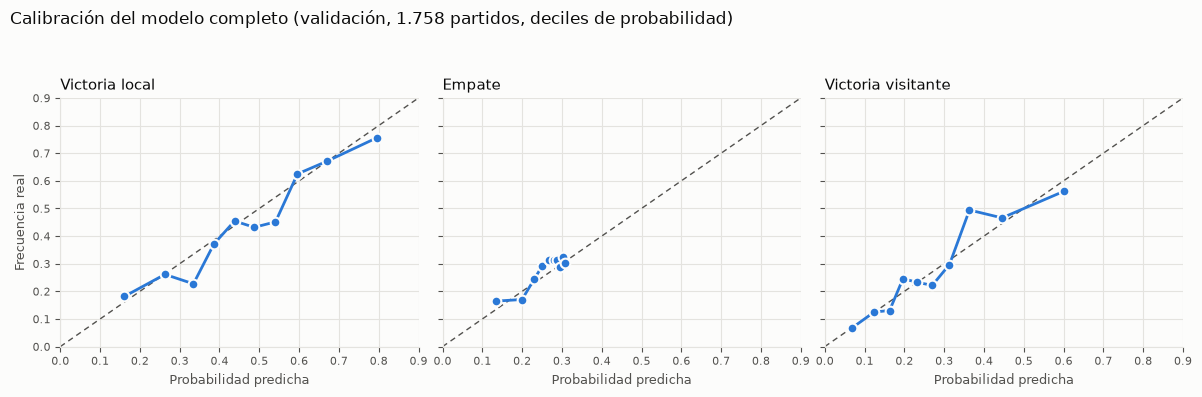

In [19]:
prob_comp = pd.concat(predicciones["Completo"]).sort_index().to_numpy()
y_valid = datos.loc[pd.concat(predicciones["Completo"]).sort_index().index, "y"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor=FONDO, sharey=True)
for ax, (clase, nombre) in zip(axes, ((2, "Victoria local"), (1, "Empate"), (0, "Victoria visitante"))):
    df = pd.DataFrame({"p": prob_comp[:, clase], "real": (y_valid == clase).astype(float)})
    df["grupo"] = pd.qcut(df.p, 10, duplicates="drop")
    g = df.groupby("grupo", observed=True).agg(p=("p", "mean"), real=("real", "mean"), n=("real", "size"))
    ax.plot([0, 1], [0, 1], color=TINTA_2, linewidth=1, linestyle=(0, (4, 3)))
    ax.plot(g.p, g.real, color=SERIE, linewidth=2, marker="o", markersize=7, markeredgecolor=FONDO, markeredgewidth=1.5)
    ax.set_title(nombre, loc="left", fontsize=11, color=TINTA)
    ax.set_xlim(0, 0.9); ax.set_ylim(0, 0.9)
    ax.set_xlabel("Probabilidad predicha", color=TINTA_2, fontsize=9)
    ax.set_facecolor(FONDO)
    ax.grid(color=REJILLA, linewidth=0.8)
    ax.tick_params(colors=TINTA_2, labelsize=8)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color(REJILLA)
axes[0].set_ylabel("Frecuencia real", color=TINTA_2, fontsize=9)
fig.suptitle("Calibración del modelo completo (validación, 1.758 partidos, deciles de probabilidad)",
             x=0.01, ha="left", fontsize=12, color=TINTA)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURES / "04_calibracion.png", dpi=150, facecolor=FONDO)
plt.show()

## Conclusiones de la validación (antes de mirar el test)

**1. La fuerza domina.** El Elo reduce el RPS en 0,028 respecto a las frecuencias históricas, con un IC 95 % muy lejos de 0 y mejora en los 5 pliegues. Quitarlo del modelo completo es, con diferencia, lo que más empeora.

**2. La forma aporta poco y no se distingue del ruido.** Añadir la forma en xG mejora en 4 de 5 pliegues (+0,0009), pero el intervalo incluye el 0. La forma en puntos aporta todavía menos. Coherente con la fase 2: el Elo ya recoge casi todo lo que la forma sabe.

**Un detalle revelador:** con la forma en xG y el Elo en el modelo, el coeficiente de la **forma en puntos es negativo** (−0,11 de media). A igualdad de fuerza y de juego reciente, un equipo que ha sumado *más* puntos de los que su xG justificaba tiende a rendir *peor* después. Interpretación más probable: esos puntos de más eran suerte, que no se mantiene (la fase 5 lo confirma por otra vía). Alternativa compatible: el Elo, que se actualiza con los resultados, reacciona de más a los últimos partidos y el modelo lo corrige. Es una **asociación condicional** dentro de un bloque que no mejora la predicción de forma significativa: un indicio, no una conclusión.

**3. El estilo no mejora la predicción; el choque de estilos la empeora ligeramente.** Añadir las 12 coordenadas de estilo no mejora (2 de 5 pliegues), y las interacciones de choque empeoran de forma pequeña pero consistente. Quitar el estilo del modelo completo **mejora** el RPS. Con 14 variables más y poca señal, el modelo aprende más ruido que patrón, pese a la regularización. Algún efecto aislado es estable en signo (llegar mucho al área rival favorece al local), pero demasiado pequeño para mejorar la predicción. El estilo describe **cómo** juega un equipo, no **cuánto** gana.

**4. No nos perdemos relaciones no lineales:** el *gradient boosting* con todas las variables es **peor** que la regresión ordinal (IC 95 % de la diferencia por encima de 0).

**5. El azar domina el partido individual.** Partiendo de la incertidumbre de las frecuencias históricas:

| Tramo | % |
|---|---|
| Se sabe antes del partido (fuerza, forma, estilo) | ≈ 12 % |
| Se decide en el juego (las ocasiones que crea cada equipo) | ≈ 15 % |
| Azar (la definición de esas ocasiones y todo lo que el xG no mide) | ≈ 72 % |

Incluso conociendo el xG del partido, quedaría la mayor parte de la incertidumbre: en un solo partido, **la mayor parte del resultado no es predecible** con esta información; la calidad se impone a lo largo de una temporada.

**6. Calibración:** las probabilidades del modelo son fiables (los puntos siguen la diagonal). La sección 17 lo comprueba también en test.

**Modelo más simple con el mejor RPS en validación:** Elo + forma en puntos + forma en xG (RPS 0,1963).

## 12. Plan de evaluación en test (fijado antes de evaluarlo)

*Redactado antes de ejecutar ninguna celda sobre las temporadas de test. **No es un prerregistro formal**: no se depositó en un registro externo con fecha y la secuencia no se puede comprobar desde el historial público de Git (ver salvedades al final de esta sección). Lo que sí se puede comprobar: la elección del modelo depende solo de la validación (secciones 5–11) y se reproduce sin ejecutar ninguna celda de test.*

**Datos de test:** 2024/25 y 2025/26, con las mismas reglas de exclusión que en validación.

**Entrenamiento del modelo final:** todas las temporadas de 2014/15 a 2023/24, con el mismo procedimiento que en validación (coordenadas de estilo y regularización ajustadas solo con esas temporadas; la regularización se elige con 2023/24 como validación interna).

**Conclusión principal (única comparación decisiva):**
- **Modelo elegido:** regresión ordinal con **Elo + forma en puntos + forma en xG**, fijado por su RPS en validación.
- Se compara con **solo Elo** mediante la diferencia de RPS partido a partido y su IC 95 % por *bootstrap* emparejado.
- Si el IC excluye el 0 a favor del elegido → la forma aporta sobre la fuerza. Si no → no hay evidencia de que la forma aporte, y se informará así.

**Se informará además, sin que cambie el modelo elegido:**
- Referencias 0 (uniforme), 1 (frecuencias históricas) y "siempre gana el local" (acierto).
- El modelo completo (con estilo y choque de estilos), para comprobar si el estilo sigue sin aportar.
- El techo informativo (xG del partido) y la descomposición antes del partido / juego / azar.
- Resultados por temporada de test.

**Compromiso:** el resultado se publica sea el que sea. Si el modelo completo saliera mejor que el elegido en el test, **no se cambiaría la elección**: se informaría como resultado a investigar.

**Salvedades (añadidas en la auditoría final, sin cambiar nada de lo anterior):**
- Las temporadas de test no se usaron para elegir el modelo, sus variables ni la regularización, pero **sí aparecen en los análisis descriptivos de las fases 2 y 3** (rachas, forma en xG frente a puntos, catálogo de estilos), que inspiraron qué bloques probar. Esa contaminación favorecería encontrar mejoras de la forma o del estilo en test; no se encontró ninguna, así que no debilita la conclusión.
- Este plan se guardó en un commit antes de evaluar el test, pero el historial de Git se consolidó en un único commit al publicar el repositorio: la secuencia no se puede verificar desde el historial público. Por eso se presenta como un plan fijado de antemano y no como un prerregistro formal.

## 13. Evaluación en test

Se ejecuta exactamente el plan de la sección 12.

In [20]:
ELEGIDO = FUERZA + FORMA_P + FORMA_XG

test_eval = test[~test.excluido].merge(xg_partido, on="id_partido", how="left").reset_index(drop=True)
entreno_final, test_eval = coordenadas_estilo(datos, test_eval)
y_t = test_eval.y.to_numpy()
print(f"Entrenamiento: {entreno_final.temporada.min()} a {entreno_final.temporada.max()} ({len(entreno_final)} partidos) · "
      f"test: {len(test_eval)} partidos ({len(test) - len(test_eval)} excluidos por las reglas)")

prob_test = {
    "0 · Uniforme": np.full((len(test_eval), 3), 1 / 3),
    "1 · Frecuencias históricas": np.tile(np.bincount(entreno_final.y, minlength=3) / len(entreno_final),
                                          (len(test_eval), 1)),
}
modelos_test = {}
for nombre, variables in (("2 · Solo Elo", FUERZA), ("Elegido · Elo + forma", ELEGIDO),
                          ("Informativo · completo (con estilo)", COMPLETO),
                          ("Techo · xG del partido (no es predicción)", TECHO)):
    modelo, lam = ajustar_ordinal(entreno_final, variables)
    modelos_test[nombre] = (modelo, variables, lam)
    prob_test[nombre] = modelo.predict_proba(test_eval[variables])

rps_test = {n: rps(p, y_t) for n, p in prob_test.items()}
tabla_test = pd.DataFrame({n: evaluar(p, y_t) for n, p in prob_test.items()}).T
tabla_test.loc["Siempre gana el local"] = [np.nan, np.nan, (y_t == 2).mean()]
tabla_test["lambda"] = pd.Series({n: m[2] for n, m in modelos_test.items()})
tabla_test.round(4)

Entrenamiento: 2014-15 a 2023-24 (3442 partidos) · test: 705 partidos (55 excluidos por las reglas)


,RPS,log_loss,acierto,lambda
0 · Uniforme,0.2366,1.0986,0.2823,NaN
1 · Frecuencias históricas,0.2259,1.0573,0.4709,NaN
2 · Solo Elo,0.1986,0.9741,0.5262,0.00
Elegido · Elo + forma,0.1987,0.9751,0.5362,0.00
Informativo · completo (con estilo),0.1973,0.9706,0.5489,0.00
Techo · xG del partido (no es predicción),0.1702,0.8815,0.5972,0.03
Siempre gana el local,NaN,NaN,0.4709,NaN


### Comparación decisiva: elegido frente a solo Elo

In [21]:
def comparar(simple, completo, n=1000):
    diferencia = rps_test[simple] - rps_test[completo]
    remuestras = [diferencia[rng.integers(0, len(diferencia), len(diferencia))].mean() for _ in range(n)]
    return diferencia.mean(), np.percentile(remuestras, 2.5), np.percentile(remuestras, 97.5)

filas = []
for simple, completo, etiqueta in (("2 · Solo Elo", "Elegido · Elo + forma", "DECISIVA · forma sobre la fuerza"),
                                   ("1 · Frecuencias históricas", "2 · Solo Elo", "Informativa · fuerza (Elo)"),
                                   ("Elegido · Elo + forma", "Informativo · completo (con estilo)", "Informativa · estilo y choque")):
    media, inf, sup = comparar(simple, completo)
    filas.append({"comparación": etiqueta, "mejora media de RPS": media, "IC 95 % inferior": inf, "IC 95 % superior": sup,
                  "¿supera el ruido?": "sí" if inf > 0 else ("empeora" if sup < 0 else "no")})
comparaciones_test = pd.DataFrame(filas)
comparaciones_test.round(5)

,comparación,mejora media de RPS,IC 95 % inferior,IC 95 % superior,¿supera el ruido?
0,DECISIVA · forma sobre la fuerza,-0.00008,-0.00217,0.00207,no
1,Informativa · fuerza (Elo),0.02731,0.01752,0.03777,sí
2,Informativa · estilo y choque,0.00136,-0.00029,0.00292,no


In [22]:
# Por temporada de test
por_temporada = pd.DataFrame({n: pd.Series(rps_test[n]).groupby(test_eval.temporada).mean()
                              for n in ["1 · Frecuencias históricas", "2 · Solo Elo", "Elegido · Elo + forma",
                                        "Informativo · completo (con estilo)"]}).T
por_temporada["partidos"] = [len(test_eval)] * len(por_temporada)
por_temporada.round(4)

temporada,2024-25,2025-26,partidos
1 · Frecuencias históricas,0.2294,0.2224,705
2 · Solo Elo,0.1973,0.1999,705
Elegido · Elo + forma,0.1987,0.1987,705
Informativo · completo (con estilo),0.1975,0.1972,705


### Descomposición en test: antes del partido, en el juego, azar

In [23]:
rps_frec_t = rps_test["1 · Frecuencias históricas"].mean()
rps_eleg_t = rps_test["Elegido · Elo + forma"].mean()
rps_techo_t = rps_test["Techo · xG del partido (no es predicción)"].mean()
descomposicion_test = pd.DataFrame({
    "tramo": ["Se sabe antes del partido", "Se decide en el juego (ocasiones creadas)", "Azar"],
    "RPS": [rps_frec_t - rps_eleg_t, rps_eleg_t - rps_techo_t, rps_techo_t],
})
descomposicion_test["% test"] = 100 * descomposicion_test.RPS / rps_frec_t
descomposicion_test["% validación"] = descomposicion["% de la incertidumbre inicial"].values
descomposicion_test.round(3)

,tramo,RPS,% test,% validación
0,Se sabe antes del partido,0.027,12.052,12.449
1,Se decide en el juego (ocasiones creadas),0.029,12.617,15.120
2,Azar,0.170,75.332,72.431


In [24]:
# Coeficientes del modelo elegido (variables estandarizadas; positivo = favorece al local)
modelo_elegido = modelos_test["Elegido · Elo + forma"][0]
pd.Series(modelo_elegido.beta, index=ELEGIDO).round(3).to_frame("coeficiente")

,coeficiente
elo_dif,0.868
forma_puntos_dif,-0.175
forma_xg_dif_dif,0.243


## 14. Resumen visual

Las diferencias de RPS entre modelos son pequeñas frente a su valor (~0,20), así que un gráfico de barras del RPS desde 0 no las mostraría. Mostramos la **mejora respecto a las frecuencias históricas** (cuánto reduce cada modelo la incertidumbre), con su IC 95 %, que sí parte de 0.

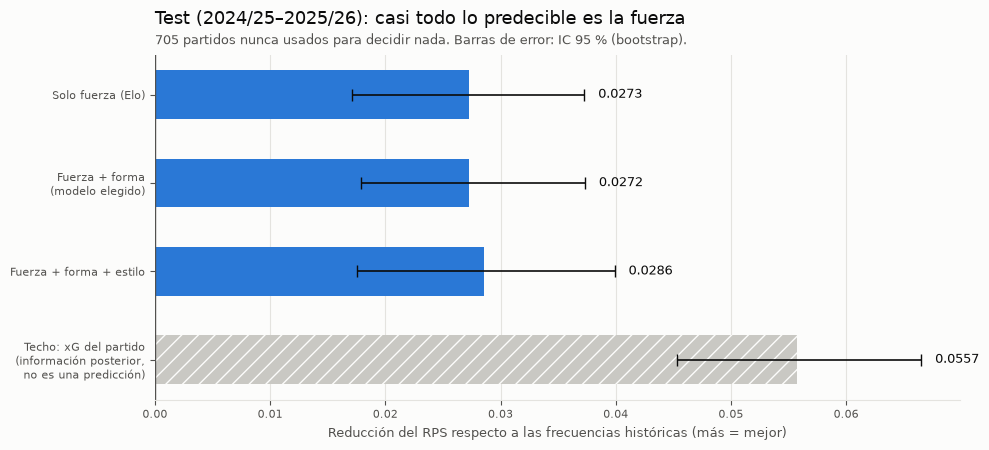

In [25]:
MODELOS_GRAFICO = ["2 · Solo Elo", "Elegido · Elo + forma", "Informativo · completo (con estilo)",
                   "Techo · xG del partido (no es predicción)"]
ETIQUETAS = ["Solo fuerza (Elo)", "Fuerza + forma\n(modelo elegido)", "Fuerza + forma + estilo",
             "Techo: xG del partido\n(información posterior,\nno es una predicción)"]
mejoras = [comparar("1 · Frecuencias históricas", m) for m in MODELOS_GRAFICO]

fig, ax = plt.subplots(figsize=(10, 4.6), facecolor=FONDO)
y = np.arange(len(MODELOS_GRAFICO))[::-1]
for i, ((media, inf, sup), etiqueta) in enumerate(zip(mejoras, ETIQUETAS)):
    techo = i == len(MODELOS_GRAFICO) - 1
    ax.barh(y[i], media, height=0.55, color="#c9c8c3" if techo else SERIE,
            hatch="//" if techo else None, edgecolor=FONDO, linewidth=0)
    ax.errorbar(media, y[i], xerr=[[media - inf], [sup - media]], color=TINTA, capsize=4, linewidth=1.2)
    ax.text(sup + 0.0012, y[i], f"{media:.4f}", va="center", fontsize=9, color=TINTA)
ax.set_yticks(y, ETIQUETAS, fontsize=9, color=TINTA)
ax.axvline(0, color=TINTA_2, linewidth=1)
ax.set_xlabel("Reducción del RPS respecto a las frecuencias históricas (más = mejor)", color=TINTA_2, fontsize=9)
ax.set_facecolor(FONDO)
ax.grid(axis="x", color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TINTA_2, labelsize=8)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(REJILLA)
ax.set_title("Test (2024/25–2025/26): casi todo lo predecible es la fuerza", loc="left", fontsize=13, color=TINTA, pad=22)
ax.text(0, 1.03, f"{len(test_eval)} partidos nunca usados para decidir nada. Barras de error: IC 95 % (bootstrap).",
        transform=ax.transAxes, fontsize=9, color=TINTA_2)
fig.tight_layout()
fig.savefig(FIGURES / "04_modelos_test.png", dpi=150, facecolor=FONDO)
plt.show()

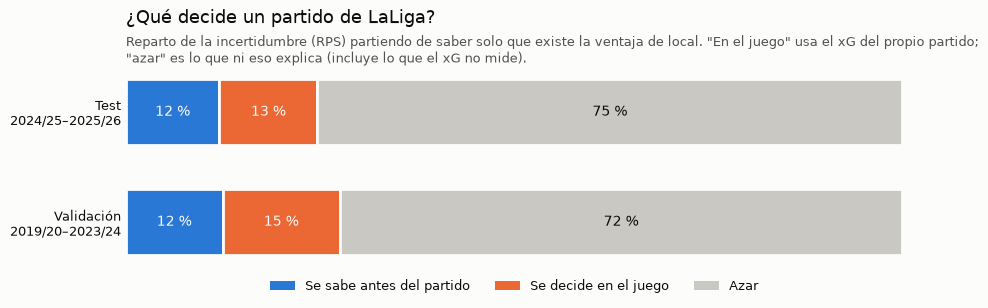

In [26]:
TRAMOS = ["Se sabe antes del partido", "Se decide en el juego", "Azar"]
COLORES_TRAMO = [SERIE, "#eb6834", "#c9c8c3"]
porcentajes = {"Test\n2024/25–2025/26": descomposicion_test["% test"].to_numpy(),
               "Validación\n2019/20–2023/24": descomposicion_test["% validación"].to_numpy()}

fig, ax = plt.subplots(figsize=(10, 3.2), facecolor=FONDO)
for fila, (nombre, valores) in enumerate(porcentajes.items()):
    izquierda = 0
    for tramo, valor, color in zip(TRAMOS, valores, COLORES_TRAMO):
        ax.barh(fila, valor, left=izquierda, height=0.6, color=color, edgecolor=FONDO, linewidth=2)
        ax.text(izquierda + valor / 2, fila, f"{valor:.0f} %", ha="center", va="center", fontsize=10,
                color=FONDO if color != "#c9c8c3" else TINTA)
        izquierda += valor
ax.set_yticks(range(len(porcentajes)), list(porcentajes), fontsize=9, color=TINTA)
ax.invert_yaxis()
ax.tick_params(length=0)
ax.set_xlim(0, 100)
ax.set_xticks([])
for lado in ax.spines.values():
    lado.set_visible(False)
ax.set_facecolor(FONDO)
for tramo, color in zip(TRAMOS, COLORES_TRAMO):
    ax.barh(np.nan, 0, color=color, label=tramo)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False, fontsize=9, labelcolor=TINTA)
ax.set_title("¿Qué decide un partido de LaLiga?", loc="left", fontsize=13, color=TINTA, pad=34)
ax.text(0, 1.04, "Reparto de la incertidumbre (RPS) partiendo de saber solo que existe la ventaja de local. "
        "\"En el juego\" usa el xG del propio partido;\n\"azar\" es lo que ni eso explica (incluye lo que el xG no mide).", transform=ax.transAxes, fontsize=9, color=TINTA_2)
fig.tight_layout()
fig.savefig(FIGURES / "04_que_decide_un_partido.png", dpi=150, facecolor=FONDO)
plt.show()

## 15. Conclusiones: ¿qué decide un partido de LaLiga?

**Resultado de la comparación decisiva (fijada en la sección 12):** el modelo elegido (Elo + forma) **no mejora** a solo Elo en test: diferencia de RPS −0,0001, IC 95 % de −0,0022 a +0,0021. **No hay evidencia de que la forma aporte sobre la fuerza.** En validación mejoraba algo (+0,001) sin superar el ruido; en test ni eso. Ausencia de evidencia no es evidencia de ausencia, pero el intervalo es estrecho: **se pueden descartar mejoras mayores de ~0,002 de RPS** (≈ 1 % del RPS).

**Lo que se confirma en datos nunca vistos:**

1. **La fuerza (Elo) es casi todo lo predecible.** Reduce el RPS en 0,027 (IC 0,018–0,038), en línea con la validación. Acierto: 52,6 % frente al 47,1 % de "siempre gana el local" (ningún modelo predice nunca un empate como resultado más probable: sección 17).
2. **La forma no añade información sobre la fuerza.** El Elo, al actualizarse partido a partido, ya incorpora el momento del equipo. Con un matiz interesante que se mantiene en test: con la forma en xG en el modelo, la forma en puntos tiene coeficiente **negativo**. Indicio de que los puntos "de más" respecto al juego son suerte que no se mantiene (asociación condicional, no una mejora predictiva).
3. **El estilo tampoco aporta de forma fiable.** En test el modelo completo sale ligeramente mejor (+0,0014), pero el IC incluye el 0 y en validación era peor. Cumpliendo el plan de la sección 12, no cambia el modelo elegido: se registra como resultado no concluyente.
4. **El azar domina el partido individual.** El reparto se repite en test: ≈ **12 %** se sabe antes del partido, ≈ **13 %** se decide en el juego (las ocasiones que crea cada equipo) y ≈ **75 %** queda sin explicar: azar en la definición de esas ocasiones y todo lo que el xG no mide.

**Respuesta a la pregunta central:** de lo que se puede saber antes de un partido, lo que importa es **la fuerza** de los equipos; ni el momento de forma ni el estilo de juego añaden información fiable. Pero lo previsible es la parte pequeña: **la mayor parte de un partido concreto no es predecible con esta información** (azar y lo que no medimos), y la calidad solo se impone con la acumulación de partidos a lo largo de una temporada.

**Limitaciones:**
- Sin cuotas de apuestas no hay comparación con el mercado; el listón son los modelos de referencia.
- El estilo se mide sin posesión (no está en las fuentes) y con variables cuya fiabilidad es moderada.
- Parámetros del Elo fijados a priori (H = 65 sin fuente citable; la regla de ascendidos los infravalora).
- El "techo" usa el xG de Understat, que es a su vez un modelo: el reparto juego/azar depende de lo bueno que sea ese xG.
- Las temporadas de test aparecen en los análisis descriptivos de las fases 2 y 3 (ver salvedades de la sección 12).
- Las diferencias de acierto entre modelos (52,6 % / 53,6 % / 54,9 %) están dentro del ruido: con 705 partidos, el error típico de un acierto es ≈ 1,9 puntos.

## 16. Exportación para Power BI

El informe final (fase 6) se construye en Power BI a partir de estas tablas. Criterio de reparto: **lo que se agrega (medias, recuentos, calibración) se calcula en Power BI** a partir de los datos por partido; **lo inferencial (intervalos por *bootstrap*) se exporta tal como se calculó aquí**, porque no se puede reproducir fielmente en DAX.

| Fichero | Contenido | ¿En Git? |
|---|---|---|
| `modelo_predicciones.csv` | Probabilidades de cada partido por modelo, **solo fuera de muestra**: validación progresiva (2019/20–2023/24) y test (2024/25–2025/26) | No (usa la forma en xG, derivada de Understat) |
| `modelo_metricas.csv` | RPS, log-loss y acierto por modelo, conjunto y temporada. Sirve para **cuadrar** las medidas DAX con el notebook | Sí |
| `modelo_comparaciones.csv` | Mejoras de RPS con su IC 95 % (*bootstrap* emparejado), en validación y en test | Sí |
| `modelo_descomposicion.csv` | Reparto de la incertidumbre: antes del partido / en el juego / azar | Sí |

⚠️ No se exporta ninguna probabilidad *dentro de muestra*: cada predicción de validación viene de un modelo que no vio esa temporada, y las de test de un modelo entrenado solo hasta 2023/24.

In [27]:
def documentar(fichero, df, descripciones, fuente, disponible_desde, momento):
    """Sustituye en el diccionario de datos las filas de `fichero` por las de sus columnas actuales."""
    assert list(descripciones) == list(df.columns), f"{fichero}: columnas sin documentar o en otro orden"
    ruta = PROCESSED / "diccionario_datos.csv"
    diccionario = pd.read_csv(ruta)
    nuevas = pd.DataFrame([{"fichero": fichero, "columna": c, "tipo": str(df[c].dtype), "descripcion": d,
                            "fuente": fuente, "disponible_desde": disponible_desde,
                            "momento": momento(c) if callable(momento) else momento}
                           for c, d in descripciones.items()])
    pd.concat([diccionario[diccionario.fichero != fichero], nuevas]).to_csv(ruta, index=False, encoding="utf-8")

In [28]:
A_RESULTADO = np.array(["2", "X", "1"])          # y: 0 visitante, 1 empate, 2 local
# nombre común → (variables, clave en la validación de la sección 8, clave en el test de la sección 13)
MODELOS_EXPORT = {
    "Frecuencias históricas": (None, "Frecuencias históricas", "1 · Frecuencias históricas"),
    "Solo Elo": (FUERZA, "Elo", "2 · Solo Elo"),
    "Elo + forma (elegido)": (ELEGIDO, "+ forma (xG)", "Elegido · Elo + forma"),
    "Completo con estilo (informativo)": (COMPLETO, "+ choque (completo)", "Informativo · completo (con estilo)"),
}


def filas_prediccion(df, prob, modelo, conjunto):
    y = df.y.to_numpy()
    return pd.DataFrame({
        "id_partido": df.id_partido.to_numpy(), "temporada": df.temporada.to_numpy(),
        "conjunto": conjunto, "modelo": modelo,
        "p_local": prob[:, 2], "p_empate": prob[:, 1], "p_visitante": prob[:, 0],
        "resultado": A_RESULTADO[y], "prediccion": A_RESULTADO[prob.argmax(1)], "acierto": prob.argmax(1) == y,
        "rps": rps(prob, y), "log_loss": log_loss(prob, y)})


# En la sección 8 solo se guardó el RPS de cada partido; se vuelven a ajustar los mismos modelos para tener las probabilidades
bloques = []
for entreno_t, valid_t in PLIEGUES:
    entreno, valid = coordenadas_estilo(datos[datos.temporada.isin(entreno_t)], datos[datos.temporada == valid_t])
    for nombre, (variables, clave_valid, _) in MODELOS_EXPORT.items():
        if variables is None:
            prob = np.tile(np.bincount(entreno.y, minlength=3) / len(entreno), (len(valid), 1))
        else:
            prob = ajustar_ordinal(entreno, variables)[0].predict_proba(valid[variables])
        assert np.allclose(rps(prob, valid.y.to_numpy()), rps_partido[clave_valid].loc[valid.index]), nombre
        bloques.append(filas_prediccion(valid, prob, nombre, "validación"))
for nombre, (_, _, clave_test) in MODELOS_EXPORT.items():
    bloques.append(filas_prediccion(test_eval, prob_test[clave_test], nombre, "test"))

modelo_predicciones = pd.concat(bloques, ignore_index=True)
assert not modelo_predicciones.duplicated(["id_partido", "modelo"]).any()
assert np.allclose(modelo_predicciones[["p_local", "p_empate", "p_visitante"]].sum(axis=1), 1)
modelo_predicciones.groupby(["conjunto", "modelo"]).agg(partidos=("rps", "size"), RPS=("rps", "mean"),
                                                         acierto=("acierto", "mean")).round(4)

partidos     RPS  acierto
conjunto   modelo                                                      
test       Completo con estilo (informativo)       705  0.1973   0.5489
           Elo + forma (elegido)                   705  0.1987   0.5362
           Frecuencias históricas                  705  0.2259   0.4709
           Solo Elo                                705  0.1986   0.5262
validación Completo con estilo (informativo)      1758  0.1974   0.5250
           Elo + forma (elegido)                  1758  0.1963   0.5216
           Frecuencias históricas                 1758  0.2255   0.4431
           Solo Elo                               1758  0.1974   0.5188

In [29]:
# Tabla de control: las medidas DAX del informe deben dar exactamente estas cifras
metricas = (modelo_predicciones.groupby(["conjunto", "modelo", "temporada"])
            .agg(partidos=("rps", "size"), rps=("rps", "mean"), log_loss=("log_loss", "mean"), acierto=("acierto", "mean"))
            .reset_index())
total = (modelo_predicciones.groupby(["conjunto", "modelo"])
         .agg(partidos=("rps", "size"), rps=("rps", "mean"), log_loss=("log_loss", "mean"), acierto=("acierto", "mean"))
         .reset_index().assign(temporada="Todas"))
siempre_local = (modelo_predicciones[modelo_predicciones.modelo == "Solo Elo"]
                 .assign(local=lambda d: d.resultado == "1")
                 .groupby(["conjunto", "temporada"]).agg(partidos=("local", "size"), acierto=("local", "mean")).reset_index())
siempre_local = pd.concat([siempre_local, siempre_local.groupby("conjunto").apply(
    lambda d: pd.Series({"temporada": "Todas", "partidos": d.partidos.sum(),
                         "acierto": np.average(d.acierto, weights=d.partidos)}), include_groups=False).reset_index()])
modelo_metricas = pd.concat([metricas, total, siempre_local.assign(modelo="Siempre gana el local")], ignore_index=True)[
    ["conjunto", "modelo", "temporada", "partidos", "rps", "log_loss", "acierto"]]

# Deben coincidir con las cifras publicadas (sección 13 y README)
control = modelo_metricas.set_index(["conjunto", "modelo", "temporada"])
assert np.isclose(control.loc[("test", "Solo Elo", "Todas"), "rps"], tabla_test.loc["2 · Solo Elo", "RPS"])
assert np.isclose(control.loc[("test", "Elo + forma (elegido)", "Todas"), "rps"], tabla_test.loc["Elegido · Elo + forma", "RPS"])
assert np.isclose(control.loc[("test", "Siempre gana el local", "Todas"), "acierto"], tabla_test.loc["Siempre gana el local", "acierto"])
modelo_metricas[modelo_metricas.temporada == "Todas"].round(4)

,conjunto,modelo,temporada,partidos,rps,log_loss,acierto
28,test,Completo con estilo (informativo),Todas,705,0.1973,0.9706,0.5489
29,test,Elo + forma (elegido),Todas,705,0.1987,0.9751,0.5362
30,test,Frecuencias históricas,Todas,705,0.2259,1.0573,0.4709
31,test,Solo Elo,Todas,705,0.1986,0.9741,0.5262
32,validación,Completo con estilo (informativo),Todas,1758,0.1974,0.9908,0.5250
33,validación,Elo + forma (elegido),Todas,1758,0.1963,0.9867,0.5216
34,validación,Frecuencias históricas,Todas,1758,0.2255,1.0746,0.4431
35,validación,Solo Elo,Todas,1758,0.1974,0.9912,0.5188
43,test,Siempre gana el local,Todas,705,NaN,NaN,0.4709
44,validación,Siempre gana el local,Todas,1758,NaN,NaN,0.4431


In [30]:
def a_filas(df, conjunto):
    return pd.DataFrame({
        "conjunto": conjunto, "comparacion": df["comparación"], "mejora_rps": df["mejora media de RPS"],
        "ic95_inferior": df["IC 95 % inferior"], "ic95_superior": df["IC 95 % superior"],
        "supera_ruido": df["¿supera el ruido?"],
        "pliegues_en_los_que_mejora": df.get("pliegues en los que mejora", pd.Series(pd.NA, index=df.index))})


# mejoras sobre frecuencias históricas en test (las del gráfico de la sección 14)
NOMBRE_COMUN = {clave_test: nombre for nombre, (_, _, clave_test) in MODELOS_EXPORT.items()}
NOMBRE_COMUN["Techo · xG del partido (no es predicción)"] = "Techo: xG del partido (no es predicción)"
sobre_frecuencias = pd.DataFrame([{"comparación": f"Sobre frecuencias: {NOMBRE_COMUN[m]}", "mejora media de RPS": media,
                                   "IC 95 % inferior": inf, "IC 95 % superior": sup}
                                  for m, (media, inf, sup) in zip(MODELOS_GRAFICO, mejoras)])
sobre_frecuencias["¿supera el ruido?"] = np.where(sobre_frecuencias["IC 95 % inferior"] > 0, "sí",
                                                  np.where(sobre_frecuencias["IC 95 % superior"] < 0, "empeora", "no"))

modelo_comparaciones = pd.concat([a_filas(significacion, "validación"), a_filas(comparaciones_test, "test"),
                                  a_filas(sobre_frecuencias, "test")], ignore_index=True)

modelo_descomposicion = pd.concat([
    pd.DataFrame({"conjunto": "validación", "orden": [1, 2, 3], "tramo": descomposicion_test.tramo,
                  "modelo_antes_del_partido": "Completo con estilo (informativo)",
                  "rps": descomposicion.RPS.to_numpy(), "porcentaje": descomposicion["% de la incertidumbre inicial"].to_numpy()}),
    pd.DataFrame({"conjunto": "test", "orden": [1, 2, 3], "tramo": descomposicion_test.tramo,
                  "modelo_antes_del_partido": "Elo + forma (elegido)",
                  "rps": descomposicion_test.RPS.to_numpy(), "porcentaje": descomposicion_test["% test"].to_numpy()}),
], ignore_index=True)
assert np.allclose(modelo_descomposicion.groupby("conjunto").porcentaje.sum(), 100)
modelo_comparaciones.round(4)

,conjunto,comparacion,mejora_rps,ic95_inferior,ic95_superior,supera_ruido,pliegues_en_los_que_mejora
0,validación,Añadir: fuerza (Elo),0.0281,0.0223,0.0337,sí,5 de 5
1,validación,Añadir: forma en puntos,0.0003,-0.0004,0.0008,no,4 de 5
2,validación,Añadir: forma en xG,0.0009,-0.0005,0.0022,no,4 de 5
3,validación,Añadir: estilo,-0.0006,-0.0016,0.0005,no,2 de 5
4,validación,Añadir: choque de estilos,-0.0005,-0.0009,-0.0001,empeora,2 de 5
5,validación,Quitar: fuerza,0.0147,0.0106,0.0185,sí,5 de 5
6,validación,Quitar: forma,0.0005,-0.0008,0.0018,no,3 de 5
7,validación,Quitar: estilo y choque,-0.0011,-0.0022,-0.0000,empeora,0 de 5
8,validación,Quitar: choque,-0.0005,-0.0009,-0.0001,empeora,2 de 5
9,test,DECISIVA · forma sobre la fuerza,-0.0001,-0.0022,0.0021,no,<NA>


In [31]:
MOMENTO_PRED = "probabilidad calculada antes del partido, fuera de muestra (resultado, acierto, rps y log_loss se conocen después)"
DESC_PREDICCIONES = {
    "id_partido": "Identificador del partido (enlaza con partidos.csv)",
    "temporada": "Temporada",
    "conjunto": "validación (2019/20–2023/24, cada temporada predicha con las anteriores) o test (2024/25–2025/26, modelo entrenado hasta 2023/24)",
    "modelo": "Frecuencias históricas / Solo Elo / Elo + forma (elegido) / Completo con estilo (informativo)",
    "p_local": "Probabilidad de victoria local", "p_empate": "Probabilidad de empate",
    "p_visitante": "Probabilidad de victoria visitante",
    "resultado": "Resultado real: 1 local, X empate, 2 visitante",
    "prediccion": "Resultado más probable según el modelo (1, X o 2)",
    "acierto": "True si el resultado más probable es el que ocurrió",
    "rps": "Ranked Probability Score del partido (0 perfecto; menor es mejor)",
    "log_loss": "Log-loss del partido (−log de la probabilidad del resultado real)",
}
DESC_METRICAS = {
    "conjunto": "validación o test", "modelo": "Modelo (incluye «Siempre gana el local», que solo tiene acierto)",
    "temporada": "Temporada, o «Todas» para el conjunto completo", "partidos": "Partidos evaluados",
    "rps": "RPS medio", "log_loss": "Log-loss medio", "acierto": "Proporción de aciertos",
}
DESC_COMPARACIONES = {
    "conjunto": "validación o test", "comparacion": "Qué se compara (añadir o quitar un bloque, o mejora sobre frecuencias)",
    "mejora_rps": "Reducción media del RPS (positivo = el modelo más completo es mejor)",
    "ic95_inferior": "Límite inferior del IC 95 % (bootstrap emparejado por partido, 1.000 remuestras)",
    "ic95_superior": "Límite superior del IC 95 %",
    "supera_ruido": "sí (IC por encima de 0) / no (incluye el 0) / empeora (IC por debajo de 0)",
    "pliegues_en_los_que_mejora": "Temporadas de validación en las que mejora (solo validación)",
}
DESC_DESCOMPOSICION = {
    "conjunto": "validación o test", "orden": "Orden del tramo (para ordenar el gráfico)",
    "tramo": "Se sabe antes del partido / se decide en el juego (ocasiones creadas) / azar",
    "modelo_antes_del_partido": "Modelo usado como «lo que se sabe antes del partido»",
    "rps": "RPS atribuido al tramo", "porcentaje": "% de la incertidumbre inicial (RPS de frecuencias históricas)",
}

for fichero, df, desc in (("modelo_predicciones.csv", modelo_predicciones, DESC_PREDICCIONES),
                          ("modelo_metricas.csv", modelo_metricas, DESC_METRICAS),
                          ("modelo_comparaciones.csv", modelo_comparaciones, DESC_COMPARACIONES),
                          ("modelo_descomposicion.csv", modelo_descomposicion, DESC_DESCOMPOSICION)):
    df.to_csv(PROCESSED / fichero, index=False, encoding="utf-8")
    documentar(fichero, df, desc, "Calculado (modelo de la fase 4)", "2019-20",
               MOMENTO_PRED if fichero == "modelo_predicciones.csv" else "resultado de la evaluación (después de los partidos)")
    print(f"{fichero}: {len(df)} filas")

modelo_predicciones.csv: 9852 filas
modelo_metricas.csv: 45 filas
modelo_comparaciones.csv: 16 filas
modelo_descomposicion.csv: 6 filas


## 17. Diagnósticos añadidos en la auditoría final (a posteriori)

⚠️ **No forman parte del plan de evaluación de la sección 12** y no cambian el modelo elegido ni la conclusión. Se calculan con las predicciones **fuera de muestra** ya exportadas (`modelo_predicciones`) para responder dos preguntas de interpretación:

1. **¿Qué significa el acierto?** Matriz de confusión: resultado real frente a resultado más probable según el modelo.
2. **¿Está bien calibrado en test?** Probabilidad media predicha frente a frecuencia real, por resultado y por tramos de probabilidad.

In [32]:
elegido = modelo_predicciones[modelo_predicciones.modelo == "Elo + forma (elegido)"]
ORDEN_RES = ["1", "X", "2"]
for conjunto, d in elegido.groupby("conjunto"):
    matriz = pd.crosstab(d.resultado, d.prediccion).reindex(index=ORDEN_RES, columns=ORDEN_RES, fill_value=0)
    print(f"{conjunto}: {len(d)} partidos · empates reales {100 * (d.resultado == 'X').mean():.1f} % · "
          f"empates predichos como más probables: {(d.prediccion == 'X').sum()} · p(empate) máxima: {d.p_empate.max():.2f}")
    display(matriz.rename_axis(index="real", columns="predicho"))


test: 705 partidos · empates reales 24.7 % · empates predichos como más probables: 0 · p(empate) máxima: 0.31


predicho,1,X,2
real,,,
1,275,0,57
X,114,0,60
2,96,0,103


validación: 1758 partidos · empates reales 27.2 % · empates predichos como más probables: 0 · p(empate) máxima: 0.31


predicho,1,X,2
real,,,
1,669,0,110
X,350,0,129
2,252,0,248


In [33]:
# Calibración en test del modelo elegido: por resultado (en conjunto) y por quintiles de probabilidad
t = elegido[elegido.conjunto == "test"]
filas = []
for columna, res in (("p_local", "1"), ("p_empate", "X"), ("p_visitante", "2")):
    real = (t.resultado == res)
    filas.append({"resultado": res, "probabilidad media predicha": t[columna].mean(), "frecuencia real": real.mean()})
display(pd.DataFrame(filas).round(3))

quintiles = []
for columna, res in (("p_local", "1"), ("p_empate", "X"), ("p_visitante", "2")):
    g = (t.assign(real=t.resultado == res, tramo=pd.qcut(t[columna], 5))
         .groupby("tramo", observed=True).agg(predicha=(columna, "mean"), real=("real", "mean"), partidos=("real", "size")))
    g["error típico de la frecuencia"] = np.sqrt(g.predicha * (1 - g.predicha) / g.partidos)
    quintiles.append(g.reset_index(drop=True).assign(resultado=res))
pd.concat(quintiles).round(3)


,resultado,probabilidad media predicha,frecuencia real
0,1,0.459,0.471
1,X,0.257,0.247
2,2,0.285,0.282


,predicha,real,partidos,error típico de la frecuencia,resultado
0,0.191,0.234,141,0.033,1
1,0.340,0.369,141,0.040,1
2,0.449,0.404,141,0.042,1
3,0.564,0.539,141,0.042,1
4,0.750,0.809,141,0.036,1
0,0.158,0.121,141,0.031,X
1,0.240,0.262,141,0.036,X
2,0.278,0.241,141,0.038,X
3,0.299,0.255,141,0.039,X
4,0.309,0.355,141,0.039,X


In [34]:
# Cola de probabilidades bajas, fuera de muestra (validación + test): ¿ocurren las sorpresas tan a menudo como se predice?
p_todas = elegido[["p_local", "p_empate", "p_visitante"]].to_numpy().ravel()
ocurrio = np.stack([elegido.resultado == r for r in ORDEN_RES], axis=1).astype(float).ravel()
(pd.DataFrame({"tramo": pd.cut(p_todas, [0, 0.1, 0.15, 0.2, 0.3]), "p": p_todas, "ocurrió": ocurrio})
 .groupby("tramo", observed=True).agg(probabilidad_media=("p", "mean"), frecuencia_real=("ocurrió", "mean"), casos=("p", "size"))
 .round(3))


,probabilidad_media,frecuencia_real,casos
tramo,,,
"(0.0, 0.1]",0.072,0.075,305
"(0.1, 0.15]",0.126,0.130,483
"(0.15, 0.2]",0.175,0.189,676
"(0.2, 0.3]",0.258,0.266,2499


**Lectura:**

- **Ningún modelo predice nunca un empate** como resultado más probable: la probabilidad de empate no pasa del ~31 % y siempre hay otro resultado más probable. Es lo habitual en fútbol, y significa que el ~25 % de partidos que acaban en empate cuenta siempre como fallo en el acierto. Por eso el acierto es una métrica **para comunicar**, no para elegir modelos: el RPS y el log-loss evalúan las probabilidades completas, incluida la del empate.
- **Calibración en test:** la probabilidad media predicha de cada resultado está a ≈ 1 punto de su frecuencia real. Por quintiles, las diferencias son del orden de su error típico (3–4 puntos con 141 partidos por tramo): la mayor, en torno a 2 errores típicos, es lo esperable por azar entre 15 tramos. Lo más llamativo: los grandes favoritos locales ganaron algo más de lo predicho (81 % frente a 75 %), dentro del ruido. Con 705 partidos no se detecta una descalibración clara, aunque la muestra no permite afinar más.
- **Cola de probabilidades bajas (fuera de muestra):** los resultados a los que el modelo daba menos de un 10 % ocurrieron con una frecuencia muy parecida a la predicha. Es la versión fuera de muestra de la comprobación que la fase 5 hace dentro de muestra.

## 18. ¿Hay evidencia estadística de que un modelo mejore a otro? (añadida a posteriori)

⚠️ **Añadida después de evaluar el test.** No forma parte del plan de la sección 12, **no cambia el modelo elegido ni ninguna decisión** (Elo, H = 65, variables, exclusiones, regularización, métricas) y **no se usa para seleccionar modelos**. Cuantifica la incertidumbre de las diferencias que la sección 13 ya publicó.

**Pregunta:** ¿las diferencias entre los tres modelos son lo bastante grandes para tener evidencia estadística de que uno mejora a otro, o son compatibles con la variabilidad muestral de 705 partidos?

| Modelo (el mismo de la sección 13, sin reentrenar) | Variables |
|---|---|
| Solo fuerza (Elo) | `elo_dif` |
| Fuerza + forma (elegido) | + `forma_puntos_dif`, `forma_xg_dif_dif` |
| Fuerza + forma + estilo | + 12 coordenadas de estilo + 2 interacciones de choque de estilos (el modelo "completo") |

**Comparaciones:** A = Elo → Elo + forma · B = Elo → Elo + forma + estilo · C = Elo + forma → Elo + forma + estilo.

**Signo:** diferencia = **modelo nuevo − modelo base**, partido a partido. En RPS y *log-loss* (menor es mejor), **negativa = mejora**. En acierto, **positiva = mejora**. *Ojo: las secciones 9 y 13 usan el signo contrario (base − nuevo, positivo = mejora).*

### Métodos y por qué

| Pieza | Elección | Justificación |
|---|---|---|
| Unidad | El partido, **emparejado**: los tres modelos predicen los mismos 705 partidos | Casi toda la variabilidad del RPS se debe a lo difícil que es cada partido, y es común a los tres modelos. Comparar medias como si fueran muestras independientes la contaría dos veces y daría intervalos mucho más anchos de lo que corresponde |
| RPS y *log-loss*: intervalo | ***Bootstrap* emparejado**: se remuestrean partidos con reemplazo y **la misma remuestra se aplica a los dos modelos**; IC 95 % percentil; **10.000 remuestras, semilla 42** (la misma matriz de remuestras para todas las comparaciones) | No supone ninguna distribución para la diferencia, y da su distribución completa |
| RPS y *log-loss*: contraste | ***t* pareada sobre las diferencias de pérdida** (H0: misma pérdida media) | Contrasta exactamente la pérdida **media**, que es lo que miden el RPS y el *log-loss*. Es la forma que toma, para predicciones a horizonte 1, el contraste de Diebold-Mariano (el estándar para comparar la precisión de dos predicciones): con la corrección de Harvey-Leybourne-Newbold, el DM con h = 1 es algebraicamente idéntico a esta *t* (lo comprueba un test), así que no se implementa aparte. Supone diferencias aproximadamente independientes y n suficiente para que la media sea aproximadamente normal; abajo se examinan con un diagnóstico, que no es una prueba de independencia |
| Descartado: Wilcoxon | — | Contrasta si la **mediana** (pseudo-mediana) de las diferencias es 0, no la **media**. El RPS y el *log-loss* son reglas de puntuación: lo que importa es la **pérdida media**. Una mediana negativa con una media nula es posible, así que Wilcoxon respondería a otra pregunta |
| Acierto | **McNemar exacto** (binomial con p = 0,5 sobre los partidos en que solo acierta uno de los dos) + **IC exacto condicionado**: Clopper-Pearson para la proporción de discordantes que acierta el nuevo, transformada a diferencia de acierto | El acierto es binario y emparejado. Solo informan los partidos discordantes (entre 23 y 40), así que se usa la versión **exacta**, no la aproximación chi-cuadrado. El IC es coherente con McNemar por construcción (excluye el 0 si y solo si p < 0,05). Se descartó el *bootstrap* para este IC: con tan pocas discordancias es discreto y anticonservador (en C daba un límite inferior de 0,000 con McNemar p = 0,09) |
| Multiplicidad | **Holm** sobre la familia completa: 3 comparaciones × 3 métricas = **9 contrastes** | Controla la probabilidad de al menos un falso positivo (FWER) sea cual sea la dependencia entre contrastes, que aquí es fuerte (mismos partidos, métricas correlacionadas). Con solo 9 contrastes y afirmaciones de "mejora", se prefiere FWER a FDR (Benjamini-Hochberg, la de la fase 5 con 72 pruebas exploratorias) |
| IC simultáneo | El mismo método al nivel 1 − 0,05/9 (Bonferroni) | Un IC 95 % individual no está ajustado: puede excluir el 0 aunque el p ajustado no sea significativo. Holm no tiene un IC simultáneo sencillo asociado; el de Bonferroni es el habitual y algo más conservador |
| Sensibilidad | *Bootstrap* por conglomerados (se remuestrean grupos enteros, lo que conserva cualquier dependencia **dentro** de cada grupo), para RPS y *log-loss*: **semana natural ISO**, de lunes a domingo (73 grupos), y **equipo local-temporada** (40 grupos) | Comprobación **parcial** de robustez: si los IC cambiaran mucho al respetar esos grupos, el *bootstrap* por partido sería demasiado optimista. Límites: la semana ISO no es la jornada (los partidos en lunes caen en la semana siguiente y hay semanas con dos jornadas); el grupo local-temporada solo recoge la dependencia entre partidos del mismo equipo **como local**; ninguno de los dos cubre la dependencia entre grupos, y con 40 grupos el *bootstrap* por conglomerados puede subestimar algo la variabilidad |

**Qué hipótesis se contrasta:** que **estos modelos ya entrenados** (una sola vez, con 2014/15–2023/24) tienen la misma pérdida esperada en partidos como los del test. La incertidumbre del entrenamiento no se incluye: la conclusión es sobre estos modelos ajustados, no sobre si la forma o el estilo "existen" en general.

**Evidencia estadística** = p ajustado por Holm < 0,05, bajo este procedimiento. Si no se alcanza, se escribe "sin evidencia suficiente para afirmar una diferencia": la diferencia observada es **compatible con la variabilidad muestral**. Eso **no significa que los modelos sean iguales** ni que la forma o el estilo no contengan ninguna información: el IC dice qué tamaños de diferencia, a favor o en contra, siguen siendo compatibles con los datos.

In [35]:
from scipy import stats
from laliga.comparacion import (METRICAS, N_REMUESTRAS, SEMILLA, comparar_modelos, comprobar_alineacion,
                                perdidas_por_partido)

# Los tres modelos de la sección 13, con su nombre común de la exportación (sección 16)
MODELOS_COMP = {"Solo Elo": "2 · Solo Elo", "Elo + forma (elegido)": "Elegido · Elo + forma",
                "Completo con estilo (informativo)": "Informativo · completo (con estilo)"}
COMPARACIONES_TEST = [
    ("Solo Elo", "Elo + forma (elegido)", "A · Elo → Elo + forma"),
    ("Solo Elo", "Completo con estilo (informativo)", "B · Elo → Elo + forma + estilo"),
    ("Elo + forma (elegido)", "Completo con estilo (informativo)", "C · Elo + forma → Elo + forma + estilo"),
]

# Pérdidas de cada partido con las probabilidades de la sección 13, ordenadas por id_partido (= orden cronológico)
perdidas = {comun: perdidas_por_partido(test_eval.id_partido, prob_test[clave], y_t).sort_index()
            for comun, clave in MODELOS_COMP.items()}
comprobar_alineacion(perdidas)                   # mismos partidos, mismo orden, mismo resultado real
assert len(perdidas["Solo Elo"]) == 705 and perdidas["Solo Elo"].index.is_monotonic_increasing
for comun, clave in MODELOS_COMP.items():         # las medias cuadran con la tabla publicada en la sección 13
    assert np.isclose(perdidas[comun].RPS.mean(), tabla_test.loc[clave, "RPS"])
    assert np.isclose(perdidas[comun].log_loss.mean(), tabla_test.loc[clave, "log_loss"])
    assert np.isclose(perdidas[comun].acierto.mean(), tabla_test.loc[clave, "acierto"])
print(f"{len(perdidas['Solo Elo'])} partidos, idénticos y en el mismo orden en los 3 modelos · "
      f"bootstrap: {N_REMUESTRAS:,} remuestras, semilla {SEMILLA}")

705 partidos, idénticos y en el mismo orden en los 3 modelos · bootstrap: 10,000 remuestras, semilla 42


### Comprobación de supuestos (RPS y *log-loss*)

Para cada diferencia partido a partido: asimetría y curtosis (colas); autocorrelación entre diferencias consecutivas en el orden de `id_partido` (por fecha; dentro de un mismo día, por orden alfabético del local, que es arbitrario); y, **solo para mostrar por qué no se usa**, el p de Wilcoxon. Es un diagnóstico descriptivo: **no es una prueba de independencia**.

In [36]:
filas = []
for base, nuevo, etiqueta in COMPARACIONES_TEST:
    for metrica in ("RPS", "log_loss"):
        d = (perdidas[nuevo][metrica] - perdidas[base][metrica]).to_numpy()
        filas.append({"comparación": etiqueta, "métrica": metrica, "media": d.mean(), "mediana": np.median(d),
                      "asimetría": stats.skew(d), "curtosis (exceso)": stats.kurtosis(d),
                      **{f"autocorr. retardo {k}": np.corrcoef(d[:-k], d[k:])[0, 1] for k in (1, 2, 3)},
                      "p t pareada": stats.ttest_rel(perdidas[nuevo][metrica], perdidas[base][metrica]).pvalue,
                      "p Wilcoxon (no se usa)": stats.wilcoxon(d).pvalue})
supuestos = pd.DataFrame(filas)

# Banda aproximada ±1,96/√n: rango del 95 % de cada autocorrelación POR SEPARADO si no hubiera autocorrelación
banda = 1.96 / np.sqrt(len(d))
autocorr = supuestos.melt(id_vars=["comparación", "métrica"], value_vars=[c for c in supuestos if c.startswith("autocorr.")])
fuera = autocorr[autocorr.value.abs() > banda]
print(f"Banda aproximada: ±{banda:.3f} · fuera de la banda: {len(fuera)} de {len(autocorr)} valores "
      f"(máximo {autocorr.value.abs().max():.3f})")
display(fuera.round(4))
assert fuera[["comparación", "variable"]].values.tolist() == [["C · Elo + forma → Elo + forma + estilo", "autocorr. retardo 1"]] * 2
supuestos.round(4)

Banda aproximada: ±0.074 · fuera de la banda: 2 de 18 valores (máximo 0.091)


,comparación,métrica,variable,value
4,C · Elo + forma → Elo + forma + estilo,RPS,autocorr. retardo 1,0.0907
5,C · Elo + forma → Elo + forma + estilo,log_loss,autocorr. retardo 1,0.0904


,comparación,métrica,media,mediana,asimetría,curtosis (exceso),autocorr. retardo 1,autocorr. retardo 2,autocorr. retardo 3,p t pareada,p Wilcoxon (no se usa)
0,A · Elo → Elo + forma,RPS,0.0001,-0.0008,0.0428,1.9744,0.0130,-0.0192,-0.0259,0.9452,0.8169
1,A · Elo → Elo + forma,log_loss,0.0010,-0.0039,0.2541,2.0896,0.0241,-0.0254,-0.0206,0.7753,0.6565
2,B · Elo → Elo + forma + estilo,RPS,-0.0013,-0.0014,0.0114,1.7182,0.0061,-0.0337,0.0054,0.3329,0.1517
3,B · Elo → Elo + forma + estilo,log_loss,-0.0035,-0.0079,0.4024,2.2763,0.0157,-0.0383,0.0057,0.4138,0.0612
4,C · Elo + forma → Elo + forma + estilo,RPS,-0.0014,-0.0009,-0.1075,2.6640,0.0907,-0.0307,0.0180,0.1130,0.0379
5,C · Elo + forma → Elo + forma + estilo,log_loss,-0.0045,-0.0043,0.0926,2.6606,0.0904,-0.0411,0.0103,0.1009,0.0192


**Lectura:**
- **Forma de la distribución:** las diferencias son casi simétricas (asimetría entre −0,1 y 0,4) y con colas moderadas (curtosis de exceso entre 1,7 y 2,7). Con 705 partidos es razonable aproximar la distribución de la media por una normal, que es lo que necesita la *t* pareada.
- **Autocorrelación:** 16 de los 18 valores están dentro de la banda aproximada. Los 2 que quedan justo fuera (≈ 0,09 frente a ±0,074) son el retardo 1 de la comparación C, en RPS y *log-loss*, dos métricas muy correlacionadas entre sí. Con 18 valores, que alguno salga de la banda es esperable por azar, pero **este diagnóstico no demuestra independencia ni descarta una dependencia débil**. Si esa autocorrelación positiva fuera real, la *t* subestimaría algo el error típico, es decir, sus p serían algo **pequeños** de más: no podría convertir un "sin evidencia" en evidencia. La sensibilidad por conglomerados de más abajo es la comprobación complementaria.

**Por qué no Wilcoxon, aunque en C dé p < 0,05:** trabaja con rangos, así que resta peso a los partidos con diferencias grandes y contrasta la pseudo-mediana de las diferencias, no su media. La pregunta es sobre la pérdida **media**, que es lo que miden el RPS y el *log-loss*, y los partidos con diferencias grandes cuentan en ella con todo su peso. Cambiar de contraste después de ver cuál da el p más pequeño sería *p-hacking*.

### Resultados

In [37]:
comparacion_test = comparar_modelos(perdidas, COMPARACIONES_TEST)

# Escala de referencia para la importancia práctica: la mejora que consigue el Elo sobre las frecuencias históricas
# en test, en la misma métrica: mejora_elo = métrica(Solo Elo) − métrica(Frecuencias históricas).
# fraccion = diferencia / mejora_elo: POSITIVA si la diferencia va en el sentido de mejora (en las tres métricas).
# (El acierto de las frecuencias históricas es el de "siempre gana el local": predicen siempre victoria local.)
mejora_elo = {m: tabla_test.loc["2 · Solo Elo", m] - tabla_test.loc["1 · Frecuencias históricas", m]
              for m in ("RPS", "log_loss", "acierto")}
comparacion_test["fraccion_de_la_mejora_elo"] = comparacion_test.diferencia / comparacion_test.metrica.map(mejora_elo)
print("Mejora del Elo sobre las frecuencias históricas en test (Elo − frecuencias): "
      + ", ".join(f"{m} {v:+.4f}" for m, v in mejora_elo.items()))

# Sensibilidad a la dependencia entre partidos: bootstrap por conglomerados (semana; equipo local-temporada)
fechas = pd.to_datetime(test_eval.set_index("id_partido").loc[perdidas["Solo Elo"].index, "fecha"])
semana = (fechas.dt.isocalendar().year.astype(str) + "-S" + fechas.dt.isocalendar().week.astype(str)).to_numpy()
local_temporada = (test_eval.set_index("id_partido").loc[perdidas["Solo Elo"].index]
                   .pipe(lambda d: d.local + " " + d.temporada)).to_numpy()
for sufijo, grupos in (("semanas", semana), ("local_temporada", local_temporada)):
    conglomerado = comparar_modelos(perdidas, COMPARACIONES_TEST, grupos=grupos)
    es_bootstrap = conglomerado.metrica != "acierto"      # el IC del acierto es exacto: no depende del bootstrap
    comparacion_test[f"ic95_{sufijo}_inferior"] = conglomerado.ic95_inferior.where(es_bootstrap)
    comparacion_test[f"ic95_{sufijo}_superior"] = conglomerado.ic95_superior.where(es_bootstrap)
print(f"Conglomerados: {len(set(semana))} semanas ISO (lunes a domingo), {len(set(local_temporada))} equipos local-temporada")


def formato(f):
    escala, dec = (100, 2) if f.metrica == "acierto" else (1, 4)      # acierto en puntos porcentuales
    num = lambda x: f"{escala * x:+.{dec}f}"
    return pd.Series({
        "Comparación": f.comparacion, "Métrica": {"RPS": "RPS", "log_loss": "Log-loss", "acierto": "Acierto (pp)"}[f.metrica],
        "Base → nuevo": f"{escala * f.valor_base:.{dec}f} → {escala * f.valor_nuevo:.{dec}f}",
        "Diferencia (nuevo − base)": num(f.diferencia), "Cambio relativo vs base": f"{100 * f.cambio_relativo_vs_base:+.1f} %",
        "IC 95 %": f"[{num(f.ic95_inferior)}, {num(f.ic95_superior)}]",
        "IC simultáneo (9)": f"[{num(f.ic_simultaneo_inferior)}, {num(f.ic_simultaneo_superior)}]",
        "Contraste": (f"McNemar exacto ({f.aciertos_solo_base:.0f} vs {f.aciertos_solo_nuevo:.0f})" if f.metrica == "acierto"
                      else "t pareada"),
        "p": f"{f.p_valor:.3f}", "p Holm": f"{f.p_holm:.3f}",
        "Fracción de la mejora Elo vs frecuencias": f"{100 * f.fraccion_de_la_mejora_elo:+.1f} %", "Evidencia": f.evidencia})


with pd.option_context("display.max_colwidth", 90):
    display(comparacion_test.apply(formato, axis=1))

Mejora del Elo sobre las frecuencias históricas en test (Elo − frecuencias): RPS -0.0273, log_loss -0.0833, acierto +0.0553


Conglomerados: 73 semanas ISO (lunes a domingo), 40 equipos local-temporada


,Comparación,Métrica,Base → nuevo,Diferencia (nuevo − base),Cambio relativo vs base,IC 95 %,IC simultáneo (9),Contraste,p,p Holm,Fracción de la mejora Elo vs frecuencias,Evidencia
0,A · Elo → Elo + forma,RPS,0.1986 → 0.1987,+0.0001,+0.0 %,"[-0.0021, +0.0022]","[-0.0030, +0.0031]",t pareada,0.945,1.000,-0.3 %,Sin evidencia suficiente para afirmar una diferencia
1,A · Elo → Elo + forma,Log-loss,0.9741 → 0.9751,+0.0010,+0.1 %,"[-0.0061, +0.0080]","[-0.0087, +0.0108]",t pareada,0.775,1.000,-1.2 %,Sin evidencia suficiente para afirmar una diferencia
2,A · Elo → Elo + forma,Acierto (pp),52.62 → 53.62,+0.99,+1.9 %,"[-0.69, +2.48]","[-1.30, +2.93]",McNemar exacto (12 vs 19),0.281,1.000,+17.9 %,Sin evidencia suficiente para afirmar una diferencia
3,B · Elo → Elo + forma + estilo,RPS,0.1986 → 0.1973,-0.0013,-0.6 %,"[-0.0039, +0.0013]","[-0.0050, +0.0023]",t pareada,0.333,1.000,+4.7 %,Sin evidencia suficiente para afirmar una diferencia
4,B · Elo → Elo + forma + estilo,Log-loss,0.9741 → 0.9706,-0.0035,-0.4 %,"[-0.0119, +0.0049]","[-0.0157, +0.0083]",t pareada,0.414,1.000,+4.2 %,Sin evidencia suficiente para afirmar una diferencia
5,B · Elo → Elo + forma + estilo,Acierto (pp),52.62 → 54.89,+2.27,+4.3 %,"[+0.39, +3.79]","[-0.34, +4.25]",McNemar exacto (12 vs 28),0.017,0.149,+41.0 %,"Sin evidencia suficiente tras corregir por multiplicidad (p sin ajustar < 0,05)"
6,C · Elo + forma → Elo + forma + estilo,RPS,0.1987 → 0.1973,-0.0014,-0.7 %,"[-0.0031, +0.0003]","[-0.0038, +0.0010]",t pareada,0.113,0.745,+5.0 %,Sin evidencia suficiente para afirmar una diferencia
7,C · Elo + forma → Elo + forma + estilo,Log-loss,0.9751 → 0.9706,-0.0045,-0.5 %,"[-0.0099, +0.0008]","[-0.0122, +0.0031]",t pareada,0.101,0.745,+5.4 %,Sin evidencia suficiente para afirmar una diferencia
8,C · Elo + forma → Elo + forma + estilo,Acierto (pp),53.62 → 54.89,+1.28,+2.4 %,"[-0.19, +2.40]","[-0.73, +2.69]",McNemar exacto (7 vs 16),0.093,0.745,+23.1 %,Sin evidencia suficiente para afirmar una diferencia


**Cómo leer las dos columnas relativas** (dos cantidades distintas):
- **Cambio relativo vs base** = diferencia / valor del modelo base. Ejemplo: RPS −0,6 % en B significa que el RPS del modelo nuevo es un 0,6 % menor que el del modelo base.
- **Fracción de la mejora Elo vs frecuencias** = diferencia / (métrica de Solo Elo − métrica de Frecuencias históricas), ambas en test (RPS −0,0273; *log-loss* −0,0833; acierto +5,5 pp). Positiva = en el sentido de mejora. Es solo una **escala** para juzgar el tamaño (cuánto es la diferencia comparada con el salto que da el Elo sobre no saber nada de los equipos), no una atribución de efecto ni una parte de la mejora del Elo.

*Acierto: entre paréntesis, partidos en que acierta solo el base frente a solo el nuevo.*

**Estabilidad del procedimiento:** la sensibilidad por conglomerados (¿cambia qué IC incluyen el 0?) y el error de Monte Carlo (5 semillas distintas).

In [38]:
sensibilidad = comparacion_test[["comparacion", "metrica", "ic95_inferior", "ic95_superior",
                                 "ic95_semanas_inferior", "ic95_semanas_superior",
                                 "ic95_local_temporada_inferior", "ic95_local_temporada_superior"]]
contiene_cero = lambda inf, sup: (sensibilidad[inf] <= 0) & (sensibilidad[sup] >= 0)
misma_lectura = (contiene_cero("ic95_inferior", "ic95_superior").eq(contiene_cero("ic95_semanas_inferior", "ic95_semanas_superior"))
                 & contiene_cero("ic95_inferior", "ic95_superior").eq(contiene_cero("ic95_local_temporada_inferior", "ic95_local_temporada_superior")))
print(f"RPS y log-loss: ¿el IC 95 % incluye el 0 en los mismos casos con los tres bootstrap? "
      f"{'sí' if misma_lectura[sensibilidad.metrica != 'acierto'].all() else 'NO'}")
display(sensibilidad[sensibilidad.metrica != "acierto"].round(5))

limites = np.array([comparar_modelos(perdidas, COMPARACIONES_TEST, semilla=s)[["ic95_inferior", "ic95_superior"]].to_numpy()
                    for s in range(1, 6)])
error_mc = pd.Series((limites.max(axis=0) - limites.min(axis=0)).max(axis=1)).groupby(comparacion_test.metrica.to_numpy()).max()
print(f"Error de Monte Carlo (5 semillas): los límites del IC 95 % varían como máximo {error_mc['RPS']:.5f} en RPS y "
      f"{error_mc['log_loss']:.5f} en log-loss (el IC del acierto es exacto: {error_mc['acierto']:.0f})")

RPS y log-loss: ¿el IC 95 % incluye el 0 en los mismos casos con los tres bootstrap? sí


,comparacion,metrica,ic95_inferior,ic95_superior,ic95_semanas_inferior,ic95_semanas_superior,ic95_local_temporada_inferior,ic95_local_temporada_superior
0,A · Elo → Elo + forma,RPS,-0.00210,0.00222,-0.00204,0.00222,-0.00204,0.00224
1,A · Elo → Elo + forma,log_loss,-0.00606,0.00801,-0.00584,0.00793,-0.00589,0.00805
3,B · Elo → Elo + forma + estilo,RPS,-0.00388,0.00131,-0.00379,0.00126,-0.00380,0.00139
4,B · Elo → Elo + forma + estilo,log_loss,-0.01192,0.00491,-0.01182,0.00501,-0.01184,0.00544
6,C · Elo + forma → Elo + forma + estilo,RPS,-0.00306,0.00031,-0.00304,0.00038,-0.00281,0.00011
7,C · Elo + forma → Elo + forma + estilo,log_loss,-0.00993,0.00083,-0.00978,0.00087,-0.00920,0.00023


Error de Monte Carlo (5 semillas): los límites del IC 95 % varían como máximo 0.00013 en RPS y 0.00036 en log-loss (el IC del acierto es exacto: 0)


### Distribución de las diferencias

Cada panel muestra, para una métrica, la diferencia media (punto), su IC 95 % (barra gruesa) y el IC simultáneo para los 9 contrastes (línea fina). La línea vertical es el 0: **si una barra la cruza, una diferencia nula es compatible con los datos** (igual que las diferencias pequeñas a favor o en contra que abarca la barra).

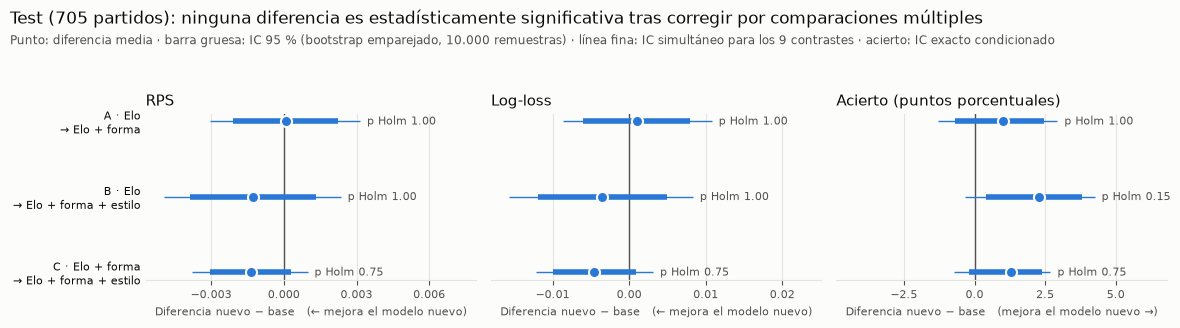

In [39]:
TITULOS = {"RPS": ("RPS", "← mejora el modelo nuevo"), "log_loss": ("Log-loss", "← mejora el modelo nuevo"),
           "acierto": ("Acierto (puntos porcentuales)", "mejora el modelo nuevo →")}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), facecolor=FONDO, sharey=True)
posiciones = np.arange(len(COMPARACIONES_TEST))[::-1]
for ax, (metrica, (titulo, sentido)) in zip(axes, TITULOS.items()):
    d = comparacion_test[comparacion_test.metrica == metrica]
    escala = 100 if metrica == "acierto" else 1
    ax.axvline(0, color=TINTA_2, linewidth=1)
    ax.hlines(posiciones, escala * d.ic_simultaneo_inferior, escala * d.ic_simultaneo_superior, color=SERIE, linewidth=1)
    ax.hlines(posiciones, escala * d.ic95_inferior, escala * d.ic95_superior, color=SERIE, linewidth=4)
    ax.plot(escala * d.diferencia, posiciones, "o", color=SERIE, markersize=8, markeredgecolor=FONDO, markeredgewidth=1.5)
    for y_pos, f in zip(posiciones, d.itertuples()):
        ax.annotate(f"p Holm {f.p_holm:.2f}", (escala * f.ic_simultaneo_superior, y_pos), xytext=(5, 0),
                    textcoords="offset points", va="center", fontsize=8, color=TINTA_2)
    ancho = escala * max(d.ic_simultaneo_inferior.abs().max(), d.ic_simultaneo_superior.abs().max())
    ax.set_xlim(-1.15 * ancho, 1.6 * ancho)
    ax.set_title(titulo, loc="left", fontsize=11, color=TINTA)
    ax.set_xlabel(f"Diferencia nuevo − base   ({sentido})", color=TINTA_2, fontsize=8)
    ax.set_facecolor(FONDO)
    ax.grid(axis="x", color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.tick_params(colors=TINTA_2, labelsize=8)
    ax.tick_params(axis="y", length=0)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(REJILLA)
axes[0].set_yticks(posiciones, [c[2].replace(" → ", "\n→ ") for c in COMPARACIONES_TEST], fontsize=8, color=TINTA)
hay_evidencia = (comparacion_test.p_holm < 0.05).any()
fig.suptitle("Test (705 partidos): " + ("alguna diferencia es significativa tras corregir por comparaciones múltiples" if hay_evidencia
             else "ninguna diferencia es estadísticamente significativa tras corregir por comparaciones múltiples"),
             x=0.01, ha="left", fontsize=12, color=TINTA)
fig.text(0.01, 0.875, "Punto: diferencia media · barra gruesa: IC 95 % (bootstrap emparejado, 10.000 remuestras) · "
         "línea fina: IC simultáneo para los 9 contrastes · acierto: IC exacto condicionado", fontsize=8.5, color=TINTA_2)
fig.tight_layout(rect=(0, 0, 1, 0.87))
fig.savefig(FIGURES / "04_comparacion_estadistica.png", dpi=150, facecolor=FONDO)
plt.show()

In [40]:
# Por temporada de test (descriptivo: ¿va la diferencia de RPS en el mismo sentido en las dos temporadas?)
temporada_de = test_eval.set_index("id_partido").loc[perdidas["Solo Elo"].index, "temporada"].to_numpy()
pd.DataFrame({etiqueta: pd.Series((perdidas[nuevo].RPS - perdidas[base].RPS).to_numpy()).groupby(temporada_de).mean()
              for base, nuevo, etiqueta in COMPARACIONES_TEST}).T.round(5)

,2024-25,2025-26
A · Elo → Elo + forma,0.00134,-0.00118
B · Elo → Elo + forma + estilo,0.00019,-0.00276
C · Elo + forma → Elo + forma + estilo,-0.00114,-0.00158


In [41]:
# Salvaguarda: el texto de conclusiones de abajo está escrito para este resultado; si cambiara, el notebook se detiene
assert not (comparacion_test.p_holm < 0.05).any()
assert (comparacion_test.p_valor < 0.05).sum() == 1
assert comparacion_test.loc[comparacion_test.p_valor < 0.05, ["comparacion", "metrica"]].values.tolist() == [
    ["B · Elo → Elo + forma + estilo", "acierto"]]
b_acierto = comparacion_test.set_index(["comparacion", "metrica"]).loc[("B · Elo → Elo + forma + estilo", "acierto")]
assert b_acierto.ic95_inferior > 0 and b_acierto.ic_simultaneo_inferior < 0          # IC individual excluye 0; el simultáneo no
en_perdidas = comparacion_test[comparacion_test.metrica != "acierto"]
assert en_perdidas.fraccion_de_la_mejora_elo.abs().max() < 0.055                     # "como mucho el 5,4 %"
assert en_perdidas.cambio_relativo_vs_base.abs().max() < 0.0075                      # "como mucho un 0,7 %"
con_estilo = comparacion_test[comparacion_test.modelo_nuevo == "Completo con estilo (informativo)"]
assert (con_estilo.fraccion_de_la_mejora_elo > 0).all()         # valores puntuales mejores en las 3 métricas (B y C)

### Conclusiones de la comparación estadística

**Conclusión:** en los 705 partidos del test, **ninguna de las 9 comparaciones proporciona evidencia estadística suficiente de una diferencia entre modelos tras corregir por comparaciones múltiples** (Holm). Las diferencias observadas son compatibles con la variabilidad muestral. Elo + forma + estilo obtiene mejores valores puntuales que los otros dos modelos en las tres métricas, pero con este análisis **no se puede afirmar que añadir la forma o el estilo produzca una mejora estadísticamente demostrada**. Tampoco demuestra lo contrario: no prueba que los modelos sean iguales ni que la forma o el estilo carezcan de información predictiva. Los IC indican qué tamaños de mejora, o de empeoramiento, siguen siendo compatibles con los datos.

**Por comparación:**

- **A · forma sobre la fuerza** (la única comparación decisiva del plan de la sección 12; como contraste único fijado de antemano no necesitaría corrección, y la conclusión es la misma sin ella): RPS +0,0001 (IC 95 % −0,0021 a +0,0022; p = 0,95). Es la conclusión de la sección 13, con más remuestras y el signo invertido. Quedan fuera del IC mejoras de RPS mayores de ~0,0021 (≈ 1,1 % del RPS del Elo). Acierto +1,0 pp (19 frente a 12 partidos discordantes; p = 0,28).
- **B · forma y estilo sobre la fuerza:** RPS −0,0013 (IC −0,0039 a +0,0013; p = 0,33), *log-loss* −0,0035 (p = 0,41). **El acierto merece una explicación aparte:** +2,3 pp, con 28 partidos en que acierta solo el nuevo frente a 12 en que acierta solo el base, y McNemar da **p = 0,017 sin ajustar**. **No basta para afirmar evidencia.** El criterio del análisis es el p ajustado sobre una familia de 9 contrastes (las 3 comparaciones × 3 métricas), fijada por las preguntas planteadas y no a la vista de los p. Con 9 contrastes al 5 % sin corregir, la probabilidad de al menos un falso positivo si no hubiera ninguna diferencia real podría acercarse al 37 % (1 − 0,95⁹, si fueran independientes). Al ser el menor p de la familia, Holm lo multiplica por 9: **p ajustado = 0,15**. De forma coherente, su IC 95 % individual [+0,4; +3,8] pp excluye el 0 porque no está ajustado, pero el **IC simultáneo [−0,3; +4,3] pp lo incluye**. Además, esa diferencia se decide en solo 40 partidos. Es el tipo de resultado aislado que puede aparecer por azar al hacer varias comparaciones; tampoco demuestra que la diferencia sea nula.
- **C · estilo sobre la forma:** RPS −0,0014 (IC −0,0031 a +0,0003; p = 0,11), *log-loss* −0,0045 (p = 0,10), acierto +1,3 pp (p = 0,09); p ajustados de 0,75. Es la comparación más cercana a una mejora, pero el IC incluye tanto mejoras de ~0,003 de RPS como un leve empeoramiento, y **en validación el estilo empeoraba** (sección 9). Por temporada de test (tabla descriptiva de arriba), la diferencia de RPS en C va en el mismo sentido en las dos temporadas, y en A en sentidos opuestos.

**Qué tamaños siguen siendo compatibles con los datos (IC 95 %):** para la forma sobre el Elo, cambios de RPS entre −0,0021 y +0,0022; para el estilo, mejoras de hasta ~0,003–0,004 de RPS (≈ 1,5–2 % del RPS del modelo base) o pequeños empeoramientos. No se descartan, por tanto, mejoras pequeñas.

**Importancia práctica:** como ninguna diferencia es estadísticamente detectable, no hay casos "detectables pero pequeños". Como escala: en RPS y *log-loss*, las diferencias puntuales cambian la métrica como mucho un 0,7 % respecto al modelo base, y equivalen como mucho al 5,4 % de la mejora del Elo sobre las frecuencias históricas. El acierto se mueve más (+1,0 a +2,3 pp, entre el 18 % y el 41 % de la mejora del Elo), pero depende de solo 23–40 partidos discordantes: es la métrica más ruidosa de las tres.

**Qué NO dice este análisis:**
- **No demuestra igualdad:** no encontrar significación no demuestra que los modelos sean iguales, ni que la forma o el estilo no tengan ningún efecto o información.
- **No demuestra causalidad:** son diferencias de capacidad predictiva entre modelos ajustados, no efectos de la forma o del estilo sobre los resultados.
- **No valida retroactivamente el diseño.** Siguen vigentes todas las limitaciones: las fases 2–3 exploraron temporadas que después forman el test (posible sesgo *post hoc*, que favorecería encontrar mejoras de la forma o el estilo); el xG histórico lo genera el modelo actual de Understat; el *early stopping* del *gradient boosting* usa un split aleatorio interno del entrenamiento (limitación metodológica de esa comprobación, no una fuga); no hay datos de jugadores, lesiones, alineaciones ni posesión; y el Elo es sencillo (H = 65 fijo, sin regresión en verano).
- **No incluye la incertidumbre del entrenamiento** (modelos ajustados una vez) ni se generaliza más allá de estas dos temporadas y de las exclusiones aplicadas. La independencia entre partidos se ha examinado con diagnósticos y una sensibilidad parcial, no demostrado.
- **No cambia el modelo elegido:** la elección se hizo en validación (sección 12) y este análisis, hecho después, no se usa para revisarla.

### Exportación

`modelo_comparacion_estadistica.csv` (versionado: solo contiene resultados agregados). `tests/test_comparacion.py` comprueba que se reproduce exactamente a partir de `modelo_predicciones.csv`.

In [42]:
DESC_COMP_ESTADISTICA = {
    "comparacion": "A, B o C: modelo base → modelo nuevo",
    "modelo_base": "Modelo de referencia de la comparación", "modelo_nuevo": "Modelo con más variables",
    "metrica": "RPS, log_loss o acierto", "partidos": "Partidos de test comparados (los mismos en los dos modelos)",
    "valor_base": "Métrica media del modelo base", "valor_nuevo": "Métrica media del modelo nuevo",
    "diferencia": "Media de (nuevo − base) por partido. RPS y log-loss: negativa = mejora; acierto: positiva = mejora",
    "cambio_relativo_vs_base": "Cambio relativo respecto al modelo base: diferencia / valor_base",
    "ic95_inferior": "IC 95 % de la diferencia. RPS y log-loss: bootstrap emparejado por partido, percentil, 10.000 remuestras, semilla 42; acierto: exacto condicionado (Clopper-Pearson sobre los discordantes)",
    "ic95_superior": "Límite superior del IC 95 %",
    "ic_simultaneo_inferior": "IC simultáneo (Bonferroni, 9 contrastes): mismo método al nivel 1 − 0,05/9",
    "ic_simultaneo_superior": "Límite superior del IC simultáneo",
    "contraste": "RPS y log-loss: t pareada sobre las diferencias de pérdida (algebraicamente igual a Diebold-Mariano con h=1 y corrección HLN); acierto: McNemar exacto",
    "estadistico": "Estadístico t pareado (vacío en McNemar)",
    "p_valor": "p bilateral sin ajustar",
    "aciertos_solo_base": "McNemar: partidos en que acierta solo el modelo base",
    "aciertos_solo_nuevo": "McNemar: partidos en que acierta solo el modelo nuevo",
    "p_holm": "p ajustado por Holm sobre los 9 contrastes (3 comparaciones × 3 métricas)",
    "evidencia": "Lectura: evidencia estadística de mejora / empeoramiento si p_holm < 0,05; si no, sin evidencia suficiente para afirmar una diferencia (no implica igualdad)",
    "fraccion_de_la_mejora_elo": "Escala de referencia: diferencia / (métrica Solo Elo − métrica Frecuencias históricas) en test; positiva = en el sentido de mejora. No es atribución de efecto",
    "ic95_semanas_inferior": "Sensibilidad (solo RPS y log-loss): IC 95 % con bootstrap por semana natural ISO, lunes a domingo (conglomerados)",
    "ic95_semanas_superior": "Sensibilidad: límite superior (semana ISO)",
    "ic95_local_temporada_inferior": "Sensibilidad (solo RPS y log-loss): IC 95 % con bootstrap por equipo local-temporada (solo recoge la dependencia como local)",
    "ic95_local_temporada_superior": "Sensibilidad: límite superior (equipo local-temporada)",
}
comparacion_test.to_csv(PROCESSED / "modelo_comparacion_estadistica.csv", index=False, encoding="utf-8")
documentar("modelo_comparacion_estadistica.csv", comparacion_test, DESC_COMP_ESTADISTICA, "Calculado (notebook 04, sección 18)",
           "2024-25", "resultado de la evaluación (después de los partidos)")
print(f"modelo_comparacion_estadistica.csv: {len(comparacion_test)} filas")

modelo_comparacion_estadistica.csv: 9 filas
